# Analyse Exploratoire Enrichie des Donnees Clients de Cartes de Credit
## Comprehension Approfondie de la Structure du Dataset

## 1. Chargement et Inspection Initiale des Donnees

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import hashlib
from datetime import datetime
warnings.filterwarnings('ignore')

# Charger le fichier de donnees ENRICHI avec données sensibles
# Cette version contient des informations personnelles à des fins de démonstration
df_with_sensitive = pd.read_csv("default_of_credit_card_clients_with_sensitive_data.csv")

print(df_with_sensitive.head())
print("Affichage des premieres lignes du dataset enrichi:")

  FIRST_NAME LAST_NAME DATE_OF_BIRTH          NAS  ID  LIMIT_BAL  SEX  \
0      Serge   Bouvier    1971-10-11  268-422-655   3    90000.0    2   
1    Etienne    Bonnet    1968-09-16  799-194-461   4    50000.0    2   
2   Philippe   Legrand    1948-10-02  746-705-665   5    50000.0    1   
3      Julie      Noël    1968-10-01  693-563-880   6    50000.0    1   
4     Michel      Roux    1976-10-06  900-746-769   7        NaN    1   

   EDUCATION  MARRIAGE   AGE  ...  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0          2         2  34.0  ...      15549    1518.0      1500      1000   
1          2         1  37.0  ...      29547    2000.0      2019      1200   
2          2         1  57.0  ...      19131    2000.0     36681     10000   
3          1         2  37.0  ...      20024    2500.0      1815       657   
4          1         2  29.0  ...     473944   55000.0     40000     38000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default_payment_next_month  random_noise  \
0      1000    

### 1.1 Dimensions et Structure du Dataset

In [42]:
print(f"Nombre de lignes: {df_with_sensitive.shape[0]}")
print(f"Nombre de colonnes: {df_with_sensitive.shape[1]}")

Nombre de lignes: 25521
Nombre de colonnes: 31


In [43]:
# Informations detaillees sur les colonnes
info_dict = {
    'Colonne': df_with_sensitive.columns,
    'Type': df_with_sensitive.dtypes,
    'Non-Null': df_with_sensitive.count(),
    'Null': df_with_sensitive.isnull().sum(),
    'Unique': df_with_sensitive.nunique()

}

info_df = pd.DataFrame(info_dict)
info_df


,Colonne,Type,Non-Null,Null,Unique
FIRST_NAME,FIRST_NAME,str,25521,0,42
LAST_NAME,LAST_NAME,str,25521,0,39
DATE_OF_BIRTH,DATE_OF_BIRTH,str,25521,0,2822
NAS,NAS,str,25521,0,25519
ID,ID,int64,25521,0,25362
LIMIT_BAL,LIMIT_BAL,float64,24261,1260,125
SEX,SEX,int64,25521,0,3
EDUCATION,EDUCATION,int64,25521,0,7
MARRIAGE,MARRIAGE,int64,25521,0,4
AGE,AGE,float64,24271,1250,57


### 1.2 Description des Colonnes et Informations Detaillees

#### Description des Colonnes du Dataset

**Informations Clients:**
- **ID** : Identifiant unique du client
- **LIMIT_BAL** : Limite de crédit allouée (en NT$ = Nouveau Taiwan dollar)
- **SEX** : Sexe du client (1 = Homme, 2 = Femme)
- **EDUCATION** : Niveau d'éducation (1 = Études supérieures, 2 = Université, 3 = Lycée, 4 = Autres)
- **MARRIAGE** : État matrimonial (1 = Marié, 2 = Célibataire, 3 = Divorcé)
- **AGE** : Âge du client (en années)

**Historique de Paiement (Mois Précédents):**
- **PAY_0** : Statut de paiement en septembre 2005 (-1=paiement en temps voulu, 1=paiement retardé d'un mois, 2=retardé de deux mois, etc.)
- **PAY_2 à PAY_6** : Statuts de paiement des mois précédents (août à avril 2005)

**Montants des Factures (NT$):**
- **BILL_AMT1 à BILL_AMT6** : Montants des factures de crédits des 6 derniers mois (septembre 2005 à avril 2005)

**Montants des Paiements (NT$):**
- **PAY_AMT1 à PAY_AMT6** : Montants des paiements des 6 derniers mois (septembre 2005 à avril 2005)

**Variable Cible:**
- **default_payment_next_month** : Défaut de paiement au mois suivant (1 = Oui - défaut, 0 = Non - pas de défaut)

**Colonnes Supplémentaires:**
- **random_noise** : Colonne de bruit aléatoire
- **LIMIT_BAL_copy** : Copie de la limite de crédit

## 3. ANONYMISATION DES DONNÉES SENSIBLES- **Sécurité des données** : Réduire les risques de vol d'identité

- **Conformité légale** : Respecter le RGPD (Règlement Général sur la Protection des Données)

### Importance de l'Anonymisation des Données- **Protection de la vie privée** : Respecter la confidentialité des clients

### 3.1 Étapes d'Anonymisation

In [44]:
# Afficher les données sensibles AVANT anonymisation
print("=" * 80)
print("DONNÉES SENSIBLES VISIBLES - AVANT ANONYMISATION")
print("=" * 80)
sensitive_cols_display = ['ID', 'FIRST_NAME', 'LAST_NAME', 'DATE_OF_BIRTH', 'NAS', 'AGE']
print("\nÉchantillon de données sensibles (5 premières lignes):")
print(df_with_sensitive[sensitive_cols_display].head())

DONNÉES SENSIBLES VISIBLES - AVANT ANONYMISATION

Échantillon de données sensibles (5 premières lignes):
   ID FIRST_NAME LAST_NAME DATE_OF_BIRTH          NAS   AGE
0   3      Serge   Bouvier    1971-10-11  268-422-655  34.0
1   4    Etienne    Bonnet    1968-09-16  799-194-461  37.0
2   5   Philippe   Legrand    1948-10-02  746-705-665  57.0
3   6      Julie      Noël    1968-10-01  693-563-880  37.0
4   7     Michel      Roux    1976-10-06  900-746-769  29.0


In [45]:
# Créer une copie pour l'anonymisation
df_anonymized = df_with_sensitive.copy()

print("\n" + "=" * 80)
print("ÉTAPE 1: SUPPRESSION DES COLONNES SENSIBLES")
print("=" * 80)

# Colonnes à supprimer (données identifiantes directes)
columns_to_drop = ['FIRST_NAME', 'LAST_NAME', 'NAS']

print(f"\nColonnes à supprimer: {columns_to_drop}")
df_anonymized = df_anonymized.drop(columns=columns_to_drop)

print(f"Dataset après suppression: Nombre de colonnes = {len(df_anonymized.columns)}")
print(f"Colonnes supprimées: ✓ {columns_to_drop}")



ÉTAPE 1: SUPPRESSION DES COLONNES SENSIBLES

Colonnes à supprimer: ['FIRST_NAME', 'LAST_NAME', 'NAS']
Dataset après suppression: Nombre de colonnes = 28
Colonnes supprimées: ✓ ['FIRST_NAME', 'LAST_NAME', 'NAS']


In [46]:
print("\n" + "=" * 80)
print("ÉTAPE 2: PSEUDONYMISATION DE L'ID")
print("=" * 80)

# Fonction pour hacher l'ID de manière irréversible
def hash_id(id_value):
    """Hash un ID pour le rendre irréversible"""
    return hashlib.sha256(str(id_value).encode()).hexdigest()[:12]

df_anonymized['ID_ANONYME'] = df_anonymized['ID'].apply(hash_id)
df_anonymized = df_anonymized.drop(columns=['ID'])

print("\nIDentifiants originaux vs anonymes (10 premiers):")
print(f"{'Original ID':<15} -> {'ID_ANONYME':<15}")
print("-" * 35)
for i, id_val in enumerate(df_with_sensitive['ID'].head(10)):
    print(f"{id_val:<15} -> {hash_id(id_val):<15}")


ÉTAPE 2: PSEUDONYMISATION DE L'ID

IDentifiants originaux vs anonymes (10 premiers):
Original ID     -> ID_ANONYME     
-----------------------------------
3               -> 4e07408562be   
4               -> 4b227777d4dd   
5               -> ef2d127de37b   
6               -> e7f6c011776e   
7               -> 7902699be42c   
8               -> 2c624232cdd2   
9               -> 19581e27de7c   
10              -> 4a44dc153642   
11              -> 4fc82b26aecb   
12              -> 6b51d431df5d   


In [47]:
print("\n" + "=" * 80)
print("ÉTAPE 3: CALCUL DE L'ÂGE ET SUPPRESSION DE LA DATE DE NAISSANCE")
print("=" * 80)

# Convertir la date de naissance en datetime
df_anonymized['DATE_OF_BIRTH'] = pd.to_datetime(df_anonymized['DATE_OF_BIRTH'])

# Calculer l'âge à partir de la date de naissance
reference_date = pd.to_datetime('2005-09-30')  # Date de référence du dataset

def calculate_age(birth_date, ref_date=reference_date):
    """Calculer l'âge basé sur la date de naissance"""
    age = (ref_date - birth_date).days // 365
    return age

df_anonymized['AGE_CALCULATED'] = df_anonymized['DATE_OF_BIRTH'].apply(calculate_age)

print("\nComparaison des âges (original vs calculé):")
print(df_anonymized[['AGE', 'DATE_OF_BIRTH', 'AGE_CALCULATED']].head(10))

# Vérification : Les âges calculés doivent être proches des âges originaux
age_diff = abs(df_anonymized['AGE'] - df_anonymized['AGE_CALCULATED'])
print(f"\nDifférence d'âge (moyenne): {age_diff.mean():.2f} ans")
print(f"Différence d'âge (max): {age_diff.max():.0f} ans")

# Supprimer la date de naissance
df_anonymized = df_anonymized.drop(columns=['DATE_OF_BIRTH'])
df_anonymized['AGE'] = df_anonymized['AGE_CALCULATED'].astype(int)
df_anonymized = df_anonymized.drop(columns=['AGE_CALCULATED'])

print("\n Date de naissance supprimée - Âge recalculé et conservé")


ÉTAPE 3: CALCUL DE L'ÂGE ET SUPPRESSION DE LA DATE DE NAISSANCE

Comparaison des âges (original vs calculé):
    AGE DATE_OF_BIRTH  AGE_CALCULATED
0  34.0    1971-10-11              33
1  37.0    1968-09-16              37
2  57.0    1948-10-02              57
3  37.0    1968-10-01              37
4  29.0    1976-10-06              29
5  23.0    1982-10-02              23
6  28.0    1977-10-03              28
7  35.0    1970-10-06              35
8  34.0    1971-10-19              33
9  51.0    1954-10-28              50

Différence d'âge (moyenne): 0.50 ans
Différence d'âge (max): 1 ans

 Date de naissance supprimée - Âge recalculé et conservé


In [48]:
print("\n" + "=" * 80)
print("RÉSUMÉ DE L'ANONYMISATION")
print("=" * 80)

print("\n COMPARAISON AVANT/APRÈS ANONYMISATION:")
print("-" * 80)

print("\nAVANT (Dataset avec données sensibles):")
print(f"  • Nombre de lignes: {df_with_sensitive.shape[0]}")
print(f"  • Nombre de colonnes: {df_with_sensitive.shape[1]}")
print(f"  • Colonnes sensibles: {['FIRST_NAME', 'LAST_NAME', 'DATE_OF_BIRTH', 'NAS']}")
print(f"\n  Échantillon:")
print(df_with_sensitive[['ID', 'FIRST_NAME', 'LAST_NAME', 'DATE_OF_BIRTH', 'NAS', 'AGE']].head(3))

print("\n" + "-" * 80)
print("\nAPRÈS (Dataset anonymisé):")
print(f"  • Nombre de lignes: {df_anonymized.shape[0]}")
print(f"  • Nombre de colonnes: {df_anonymized.shape[1]}")
print(f"  • Colonnes supprimées: {['FIRST_NAME', 'LAST_NAME', 'NAS', 'DATE_OF_BIRTH']}")
print(f"  • ID remplacé par: ID_ANONYME (hash SHA-256)")
print(f"\n  Échantillon:")
print(df_anonymized[['ID_ANONYME', 'AGE', 'LIMIT_BAL', 'EDUCATION', 'MARRIAGE']].head(3))

print("\n" + "=" * 80)
print(" ANONYMISATION RÉUSSIE!")
print("=" * 80)

# Sauvegarder le dataset anonymisé
output_file_anonymized = "default_of_credit_card_clients_anonymized.csv"
df_anonymized.to_csv(output_file_anonymized, index=False)
print(f"\n Dataset anonymisé sauvegardé dans: {output_file_anonymized}")

# Mettre à jour df pour utiliser le dataset anonymisé pour les analyses suivantes
df = df_anonymized.copy()
print("\nLe dataset 'df' a été mis à jour avec les données anonymisées pour les analyses suivantes.")


RÉSUMÉ DE L'ANONYMISATION

 COMPARAISON AVANT/APRÈS ANONYMISATION:
--------------------------------------------------------------------------------

AVANT (Dataset avec données sensibles):
  • Nombre de lignes: 25521
  • Nombre de colonnes: 31
  • Colonnes sensibles: ['FIRST_NAME', 'LAST_NAME', 'DATE_OF_BIRTH', 'NAS']

  Échantillon:
   ID FIRST_NAME LAST_NAME DATE_OF_BIRTH          NAS   AGE
0   3      Serge   Bouvier    1971-10-11  268-422-655  34.0
1   4    Etienne    Bonnet    1968-09-16  799-194-461  37.0
2   5   Philippe   Legrand    1948-10-02  746-705-665  57.0

--------------------------------------------------------------------------------

APRÈS (Dataset anonymisé):
  • Nombre de lignes: 25521
  • Nombre de colonnes: 27
  • Colonnes supprimées: ['FIRST_NAME', 'LAST_NAME', 'NAS', 'DATE_OF_BIRTH']
  • ID remplacé par: ID_ANONYME (hash SHA-256)

  Échantillon:
     ID_ANONYME  AGE  LIMIT_BAL  EDUCATION  MARRIAGE
0  4e07408562be   33    90000.0          2         2
1  4b227777d

In [49]:
print("\n" + "=" * 80)
print("DETAILS PAR VARIABLE - ANALYSE STATISTIQUE")
print("=" * 80)

# Créer un DataFrame de synthèse
quality_summary_data = []

for col in df.select_dtypes(include=[np.number]).columns:
    col_data = df[col].dropna()
    
    summary = {
        'Colonne': col,
        'Type': str(df[col].dtype),
        'Non-Null': df[col].count(),
        'Null': df[col].isnull().sum(),
        'Min': col_data.min(),
        'Max': col_data.max(),
        'Moyenne': col_data.mean(),
        'Ecart-type': col_data.std(),
        'Uniques': df[col].nunique()
    }
    quality_summary_data.append(summary)

quality_summary_df = pd.DataFrame(quality_summary_data)

print("\nSYNTHESE STATISTIQUE:")
print(quality_summary_df.to_string())

print("\n" + "=" * 80)
print("RECOMMANDATIONS DE NETTOYAGE")
print("=" * 80)

# Recommandation 1: Valeurs hors plage
if len(quality_issues) > 0:
    print("\n[1] VALEURS HORS PLAGE A CORRIGER:")
    for col, info in quality_issues.items():
        print(f"  - {col}: {info['nombre']} valeurs a nettoyer (somme: {info['somme']:.2f})")
        print(f"    Plage valide: [{info['plage_valide'][0]}, {info['plage_valide'][1]}]")
        print(f"    Action: Filtrer ou imputer les valeurs hors plage")

# Recommandation 2: Montants suspects
if len(suspicious_amounts) > 0:
    print("\n[2] MONTANTS NEGATIFS A VERIFIER:")
    for col, info in suspicious_amounts.items():
        print(f"  - {col}: {info['nombre']} valeurs negatives (somme: {info['somme']:.2f})")
        print(f"    Action: Verifier si negatif est valide ou erreur de saisie")

# Recommandation 3: Asymétrie
if len(skewness_issues) > 0:
    print("\n[3] VARIABLES AVEC ASYMETRIE FORTE:")
    for col, skew in skewness_issues.items():
        print(f"  - {col}: Asymetrie = {skew:.4f}")
        print(f"    Action: Envisager transformation log ou Box-Cox")

# Recommandations générales
print("\n[4] RECOMMANDATIONS GENERALES:")
if complete_duplicates > 0:
    print(f"  - Supprimer {complete_duplicates} lignes dupliquees")
    print(f"    Action: df = df.drop_duplicates()")

print("  - Valider les plages en consultation avec le domaine metier")
print("  - Documenter toutes les decisions de nettoyage")
print("  - Re-valider la qualite apres nettoyage")

print("\n" + "=" * 80)


DETAILS PAR VARIABLE - ANALYSE STATISTIQUE

SYNTHESE STATISTIQUE:
                       Colonne     Type  Non-Null  Null            Min           Max        Moyenne     Ecart-type  Uniques
0                    LIMIT_BAL  float64     24261  1260   10000.000000  1.000000e+07  207560.776555  326640.411011      125
1                          SEX    int64     25521     0       1.000000  9.900000e+01       3.555895      13.637967        3
2                    EDUCATION    int64     25521     0       0.000000  6.000000e+00       1.844873       0.801225        7
3                     MARRIAGE    int64     25521     0       0.000000  3.000000e+00       1.556091       0.521706        4
4                          AGE    int64     25521     0      -6.000000  7.900000e+01      34.851887      11.608396       62
5                        PAY_0    int64     25521     0      -2.000000  8.000000e+00      -0.144352       1.017561       11
6                        PAY_2    int64     25521     0      -2.0

In [50]:
print("\n" + "=" * 80)
print("RAPPORT DE QUALITE DES DONNEES - RESUME")
print("=" * 80)

# Créer un rapport structuré
quality_report = {
    'Variables hors plage': len(quality_issues),
    'Montants negatifs anormaux': len(suspicious_amounts),
    'Statuts de paiement invalides': len(invalid_pay_status),
    'Lignes completement dupliquees': complete_duplicates,
    'Colonnes avec asymetrie forte': len(skewness_issues),
    'Colonnes sans variation': len(low_variation_cols)
}

print("\nRESUME DES PROBLEMES DETECTES:")
print("-" * 80)
total_anomalies = 0
for issue, count in quality_report.items():
    if count > 0:
        print(f"  [ANOMALIE] {issue}: {count}")
        total_anomalies += count
    else:
        print(f"  [OK] {issue}: {count}")

print(f"\nTotal des anomalies detectees: {total_anomalies}")

# Score de qualité global
total_issues = sum(quality_report.values())
quality_score = max(0, 100 - (total_issues * 5))

print("\n" + "=" * 80)
print(f"SCORE DE QUALITE GLOBAL: {quality_score:.1f}/100")
print("=" * 80)

if quality_score >= 90:
    print("EVALUATION: EXCELLENT - Les donnees sont de haute qualite")
elif quality_score >= 75:
    print("EVALUATION: BON - Les donnees sont globalement fiables avec quelques ameliorations")
elif quality_score >= 50:
    print("EVALUATION: MOYEN - Nettoyage modere recommande avant modelisation")
else:
    print("EVALUATION: FAIBLE - Nettoyage approfondi recommande avant utilisation")


RAPPORT DE QUALITE DES DONNEES - RESUME

RESUME DES PROBLEMES DETECTES:
--------------------------------------------------------------------------------
  [ANOMALIE] Variables hors plage: 7
  [ANOMALIE] Montants negatifs anormaux: 6
  [ANOMALIE] Statuts de paiement invalides: 6
  [OK] Lignes completement dupliquees: 0
  [ANOMALIE] Colonnes avec asymetrie forte: 16
  [OK] Colonnes sans variation: 0

Total des anomalies detectees: 35

SCORE DE QUALITE GLOBAL: 0.0/100
EVALUATION: FAIBLE - Nettoyage approfondi recommande avant utilisation


In [51]:
print("\n" + "=" * 80)
print("ETAPE 3: IDENTIFICATION DES PATTERNS SUSPECTS")
print("=" * 80)

# 1. Vérifier les valeurs constantes (aucune variation)
print("\n[CONTROLE] Detection de colonnes avec peu de variation:")
low_variation_cols = []
for col in df.select_dtypes(include=[np.number]).columns:
    unique_count = df[col].nunique()
    if unique_count <= 1:
        print(f"  ANOMALIE: {col} - Seulement {unique_count} valeur unique")
        low_variation_cols.append(col)
    elif unique_count <= 5:
        print(f"  ATTENTION: {col} - Seulement {unique_count} valeurs uniques: {sorted(df[col].unique())}")

if not any(len(df[col].unique()) <= 5 for col in df.select_dtypes(include=[np.number]).columns):
    print("  OK - Variation normale detectee")

# 2. Vérifier les distributions extrêmes
print("\n[CONTROLE] Detection des distributions extremes:")
skewness_issues = {}
for col in df.select_dtypes(include=[np.number]).columns:
    skew_value = df[col].skew()
    if abs(skew_value) > 2:
        skewness_issues[col] = skew_value
        print(f"  ANOMALIE: {col} - Asymetrie forte = {skew_value:.4f}")

if len(skewness_issues) == 0:
    print("  OK - Distributions normales")

# 3. Vérifier les doublons complets
print("\n[CONTROLE] Analyse des doublons:")
complete_duplicates = df.duplicated().sum()
if complete_duplicates > 0:
    print(f"  ANOMALIE: Nombre de lignes dupliquees: {complete_duplicates}")
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
    print(f"  Echantillon des premiers doublons:")
    print(duplicate_rows.head(10).to_string())
else:
    print("  OK - Aucun doublon detecte")

# 4. Vérifier la proportion de zéros
print("\n[CONTROLE] Analyse des proportions de zeros:")
zero_anomalies = {}
for col in variables_with_zero:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        zero_pct = (zero_count / len(df)) * 100
        if zero_pct > 50:
            zero_anomalies[col] = {
                'pourcentage': zero_pct,
                'nombre': zero_count,
                'somme': df[df[col] == 0][col].sum()
            }
            print(f"  ANOMALIE: {col} - {zero_pct:.1f}% de zeros ({zero_count} valeurs)")

if len(zero_anomalies) == 0:
    print("  OK - Proportions de zeros normales")


ETAPE 3: IDENTIFICATION DES PATTERNS SUSPECTS

[CONTROLE] Detection de colonnes avec peu de variation:
  ATTENTION: SEX - Seulement 3 valeurs uniques: [np.int64(1), np.int64(2), np.int64(99)]
  ATTENTION: MARRIAGE - Seulement 4 valeurs uniques: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  ATTENTION: default_payment_next_month - Seulement 2 valeurs uniques: [np.int64(0), np.int64(1)]

[CONTROLE] Detection des distributions extremes:
  ANOMALIE: LIMIT_BAL - Asymetrie forte = 9.2640
  ANOMALIE: SEX - Asymetrie forte = 6.8471
  ANOMALIE: BILL_AMT1 - Asymetrie forte = 17.9428
  ANOMALIE: BILL_AMT2 - Asymetrie forte = 2.6427
  ANOMALIE: BILL_AMT3 - Asymetrie forte = 3.0984
  ANOMALIE: BILL_AMT4 - Asymetrie forte = 2.7917
  ANOMALIE: BILL_AMT5 - Asymetrie forte = 2.8586
  ANOMALIE: BILL_AMT6 - Asymetrie forte = 2.8288
  ANOMALIE: PAY_AMT1 - Asymetrie forte = 14.3378
  ANOMALIE: PAY_AMT2 - Asymetrie forte = 29.1870
  ANOMALIE: PAY_AMT3 - Asymetrie forte = 16.8297
  ANOMALIE: PAY_AMT

In [52]:
print("\n" + "=" * 80)
print("ETAPE 2: DETECTION DES VALEURS ABERRANTES ET INVALIDES")
print("=" * 80)

anomalies_detected = {}

# 1. Vérifier AGE pour les valeurs suspectes (0, 999, 9999, etc.)
print("\n[CONTROLE] Analyse variable AGE:")
age_suspicious = df[df['AGE'].isin([0, 999, 9999, -1, -999])]
if len(age_suspicious) > 0:
    print(f"  Valeurs suspectes trouvees: {len(age_suspicious)}")
    print(f"  Valeurs: {sorted(age_suspicious['AGE'].unique())}")
    print(f"  Somme: {age_suspicious['AGE'].sum():.2f}")
    print(f"  Echantillon de lignes suspectes:")
    print(age_suspicious[['AGE']].head(10).to_string())
    anomalies_detected['AGE_suspicious'] = len(age_suspicious)
else:
    print("  OK - Aucune valeur suspecte detectee")

# 2. Vérifier les bornes pour AGE
age_too_old = df[df['AGE'] > 100]
age_too_young = df[df['AGE'] < 18]
if len(age_too_old) > 0:
    print(f"  Anomalie: AGE > 100 ans: {len(age_too_old)} observations")
    print(f"  Somme: {age_too_old['AGE'].sum():.2f}")
    print(f"  Echantillon:")
    print(age_too_old[['AGE']].head(5).to_string())
if len(age_too_young) > 0:
    print(f"  Anomalie: AGE < 18 ans: {len(age_too_young)} observations")
    print(f"  Somme: {age_too_young['AGE'].sum():.2f}")

# 3. Vérifier les variables de montant (BILL_AMT, PAY_AMT)
print("\n[CONTROLE] Analyse des montants de facturation et paiement:")
bill_cols = [col for col in df.columns if 'BILL_AMT' in col]
pay_cols = [col for col in df.columns if 'PAY_AMT' in col]

suspicious_amounts = {}
for col in bill_cols + pay_cols:
    if col in df.columns:
        neg_values = df[df[col] < 0]
        if len(neg_values) > 0:
            suspicious_amounts[col] = {
                'nombre': len(neg_values),
                'somme': neg_values[col].sum()
            }

if len(suspicious_amounts) > 0:
    for col, info in suspicious_amounts.items():
        print(f"  Anomalie: {col} a des valeurs negatives: {info['nombre']} observations")
        print(f"  Somme totale: {info['somme']:.2f}")
        print(f"  Echantillon:")
        print(df[df[col] < 0][[col]].head(5).to_string())
else:
    print("  OK - Aucune valeur negative anormale detectee")

# 4. Vérifier les variables de statut de paiement
print("\n[CONTROLE] Analyse des statuts de paiement (PAY_0, PAY_2-PAY_6):")
pay_status_cols = [col for col in df.columns if col.startswith('PAY_') and col != 'PAY_AMT1' and col != 'PAY_AMT2' 
                   and col != 'PAY_AMT3' and col != 'PAY_AMT4' and col != 'PAY_AMT5' and col != 'PAY_AMT6']

invalid_pay_status = {}
for col in pay_status_cols:
    if col in df.columns:
        invalid = df[(df[col] < -1) | (df[col] > 8)]
        if len(invalid) > 0:
            invalid_pay_status[col] = {
                'nombre': len(invalid),
                'somme': invalid[col].sum(),
                'valeurs_uniques': sorted(invalid[col].unique())
            }

if len(invalid_pay_status) > 0:
    for col, info in invalid_pay_status.items():
        print(f"  Anomalie: {col} a des valeurs invalides: {info['nombre']} observations")
        print(f"  Valeurs uniques: {info['valeurs_uniques']}")
        print(f"  Somme: {info['somme']:.2f}")
        print(f"  Echantillon:")
        print(df[(df[col] < -1) | (df[col] > 8)][[col]].head(5).to_string())
else:
    print("  OK - Tous les statuts de paiement sont valides")


ETAPE 2: DETECTION DES VALEURS ABERRANTES ET INVALIDES

[CONTROLE] Analyse variable AGE:
  OK - Aucune valeur suspecte detectee
  Anomalie: AGE < 18 ans: 510 observations
  Somme: -2819.00

[CONTROLE] Analyse des montants de facturation et paiement:
  Anomalie: BILL_AMT1 a des valeurs negatives: 496 observations
  Somme totale: -859497.00
  Echantillon:
     BILL_AMT1
49      -190.0
67     -2000.0
75       -81.0
82      -103.0
112    -1100.0
  Anomalie: BILL_AMT2 a des valeurs negatives: 591 observations
  Somme totale: -777022.00
  Echantillon:
     BILL_AMT2
26        -131
49       -9850
75        -303
82        -103
112      -1100
  Anomalie: BILL_AMT3 a des valeurs negatives: 576 observations
  Somme totale: -790911.00
  Echantillon:
     BILL_AMT3
26        -527
49       -9850
52        -684
82        -103
246         -2
  Anomalie: BILL_AMT4 a des valeurs negatives: 594 observations
  Somme totale: -948676.00
  Echantillon:
     BILL_AMT4
26        -923
82        -103
96        

In [53]:
print("\n" + "=" * 80)
print("ETAPE 1: VERIFICATION DES PLAGES DE VALEURS")
print("=" * 80)

# Analyser chaque variable avec une plage définie
quality_issues = {}

for col, (min_val, max_val) in valid_ranges.items():
    if col not in df.columns:
        continue
    
    # Vérifier les valeurs en dehors de la plage
    out_of_range = df[(df[col] < min_val) | (df[col] > max_val)]
    
    if len(out_of_range) > 0:
        quality_issues[col] = {
            'nombre': len(out_of_range),
            'pourcentage': (len(out_of_range) / len(df)) * 100,
            'min_invalide': out_of_range[col].min(),
            'max_invalide': out_of_range[col].max(),
            'plage_valide': (min_val, max_val),
            'somme': out_of_range[col].sum(),
            'valeurs': out_of_range[col].unique()
        }
        
        print(f"\n[ANOMALIE] {col}:")
        print(f"  Plage valide: [{min_val}, {max_val}]")
        print(f"  Nombre de valeurs invalides: {len(out_of_range)} ({(len(out_of_range) / len(df)) * 100:.2f}%)")
        print(f"  Minimum invalide: {out_of_range[col].min()}")
        print(f"  Maximum invalide: {out_of_range[col].max()}")
        print(f"  Somme des valeurs invalides: {out_of_range[col].sum():.2f}")
        print(f"  Valeurs uniques invalides: {sorted(out_of_range[col].unique())[:10]}")  # Affiche les 10 premières
        print(f"  Echantillon de lignes avec anomalies:")
        print(out_of_range[[col]].head(10).to_string())

if len(quality_issues) == 0:
    print("\nOK - Toutes les variables sont dans leurs plages valides")


ETAPE 1: VERIFICATION DES PLAGES DE VALEURS

[ANOMALIE] AGE:
  Plage valide: [18, 120]
  Nombre de valeurs invalides: 510 (2.00%)
  Minimum invalide: -6
  Maximum invalide: -5
  Somme des valeurs invalides: -2819.00
  Valeurs uniques invalides: [np.int64(-6), np.int64(-5)]
  Echantillon de lignes avec anomalies:
     AGE
26    -5
46    -5
57    -6
157   -6
159   -6
211   -6
246   -6
321   -6
342   -5
374   -6

[ANOMALIE] LIMIT_BAL:
  Plage valide: [1000, 1000000]
  Nombre de valeurs invalides: 314 (1.23%)
  Minimum invalide: 1100000.0
  Maximum invalide: 10000000.0
  Somme des valeurs invalides: 791600000.00
  Valeurs uniques invalides: [np.float64(1100000.0), np.float64(1200000.0), np.float64(1300000.0), np.float64(1400000.0), np.float64(1500000.0), np.float64(1600000.0), np.float64(1700000.0), np.float64(1800000.0), np.float64(1900000.0), np.float64(2000000.0)]
  Echantillon de lignes avec anomalies:
     LIMIT_BAL
115  3500000.0
135  3600000.0
170  3300000.0
230  2800000.0
432  270

In [54]:
print("=" * 80)
print("VÉRIFICATION DE LA QUALITÉ DES DONNÉES")
print("=" * 80)

# Définir les plages valides pour chaque variable
valid_ranges = {
    'AGE': (18, 120),  # Âge réaliste
    'LIMIT_BAL': (1000, 1000000),  # Limite de crédit en NT$
    'SEX': (1, 2),  # 1=Homme, 2=Femme (catégorique)
    'EDUCATION': (1, 4),  # 1-4 = catégories d'éducation
    'MARRIAGE': (1, 3),  # 1-3 = états matrimoniaux
    'PAY_0': (-1, 8),  # Statut de paiement (-1 à 8)
    'LIMIT_BAL_copy': (1000, 1000000),  # Copie de limite de crédit
    'random_noise': (-np.inf, np.inf),  # Pas de limite
}

# Variables qui acceptent des valeurs 0
variables_with_zero = ['PAY_0', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

print("\nETAPES DE VERIFICATION:")
print("  1. Verification des plages de valeurs")
print("  2. Detection des valeurs aberrantes et invalides")
print("  3. Identification des patterns suspects")
print("  4. Generation du rapport de qualite")

VÉRIFICATION DE LA QUALITÉ DES DONNÉES

ETAPES DE VERIFICATION:
  1. Verification des plages de valeurs
  2. Detection des valeurs aberrantes et invalides
  3. Identification des patterns suspects
  4. Generation du rapport de qualite


---

## 3.2 Vérification de la Qualité des Données

### Importance du Contrôle de Qualité

L'évaluation de la qualité des données est cruciale pour:
- **Déterminer la fiabilité** des analyses ultérieures
- **Identifier les erreurs** de saisie ou de codage (ex: AGE = 9999)
- **Détecter les anomalies** et les valeurs non realistes
- **Évaluer la complétude** et la cohérence des données
- **Décider du nettoyage** nécessaire avant la modélisation

---
## 4. Analyse des Valeurs Manquantes
### 4.1 Detection des Valeurs Manquantes

In [55]:
# Compter les valeurs manquantes
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Colonne': missing_count.index,
    'Nombre_Manquant': missing_count.values,
    'Pourcentage': missing_percent.values
}).sort_values('Nombre_Manquant', ascending=False)

missing_df = missing_df[missing_df['Nombre_Manquant'] > 0]

if len(missing_df) > 0:
    print("Colonnes avec valeurs manquantes:")
    print(missing_df)
else:
    print("Aucune valeur manquante detectée!")

Colonnes avec valeurs manquantes:
           Colonne  Nombre_Manquant  Pourcentage
11       BILL_AMT1             1280     5.015477
17        PAY_AMT1             1276     4.999804
0        LIMIT_BAL             1260     4.937111
25  LIMIT_BAL_copy             1260     4.937111


### 4.2 Visualisation des Valeurs Manquantes

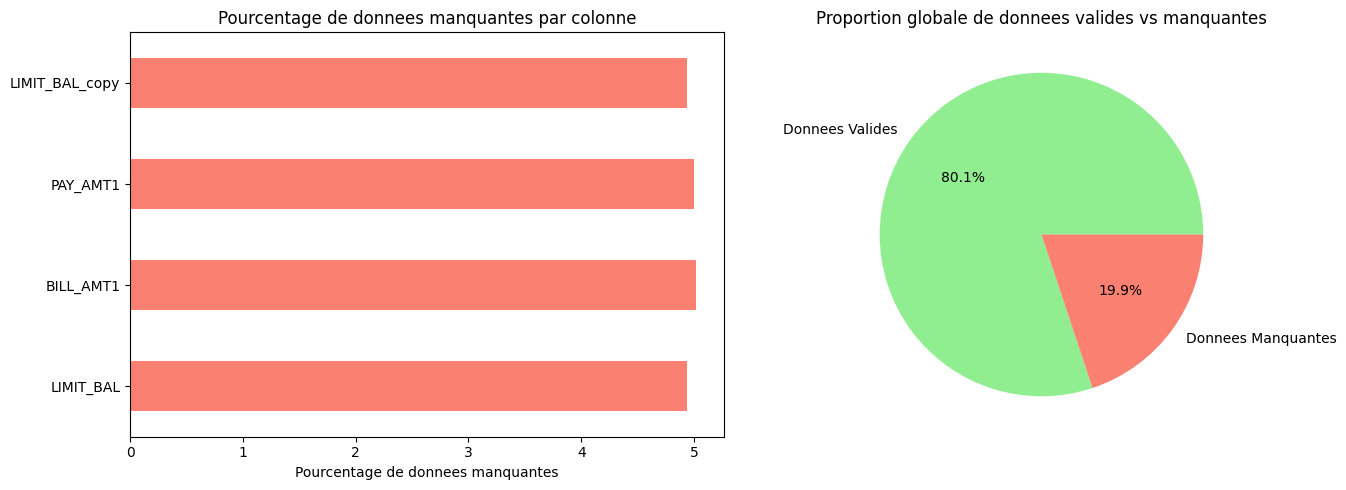

In [56]:
if missing_percent.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Graphique en barres des valeurs manquantes
    missing_percent[missing_percent > 0].plot(kind='barh', ax=axes[0], color='salmon')
    axes[0].set_xlabel('Pourcentage de donnees manquantes')
    axes[0].set_title('Pourcentage de donnees manquantes par colonne')
    
    # Graphique circulaire du total
    total_missing = missing_percent.sum()
    axes[1].pie([100 - total_missing, total_missing], 
                labels=['Donnees Valides', 'Donnees Manquantes'],
                autopct='%1.1f%%',
                colors=['lightgreen', 'salmon'])
    axes[1].set_title('Proportion globale de donnees valides vs manquantes')
    
    plt.tight_layout()
    plt.show()
else:
    print("Pas de valeurs manquantes - pas de graphique a afficher")

---

## 5. Analyse des Valeurs Aberrantes (Outliers)

### 5.1 Selection des Colonnes Numeriques

In [57]:
# Selectionner les colonnes numeriques
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Colonnes numeriques: {len(num_cols)}")
print(f"Colonnes categoriques: {len(cat_cols)}")
print(f"\nColonnes numeriques: {num_cols}")
print(f"\nColonnes categoriques: {cat_cols}")

Colonnes numeriques: 26
Colonnes categoriques: 1

Colonnes numeriques: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_payment_next_month', 'random_noise', 'LIMIT_BAL_copy']

Colonnes categoriques: ['ID_ANONYME']


### 5.2 Boxplots de toutes les Variables Numeriques

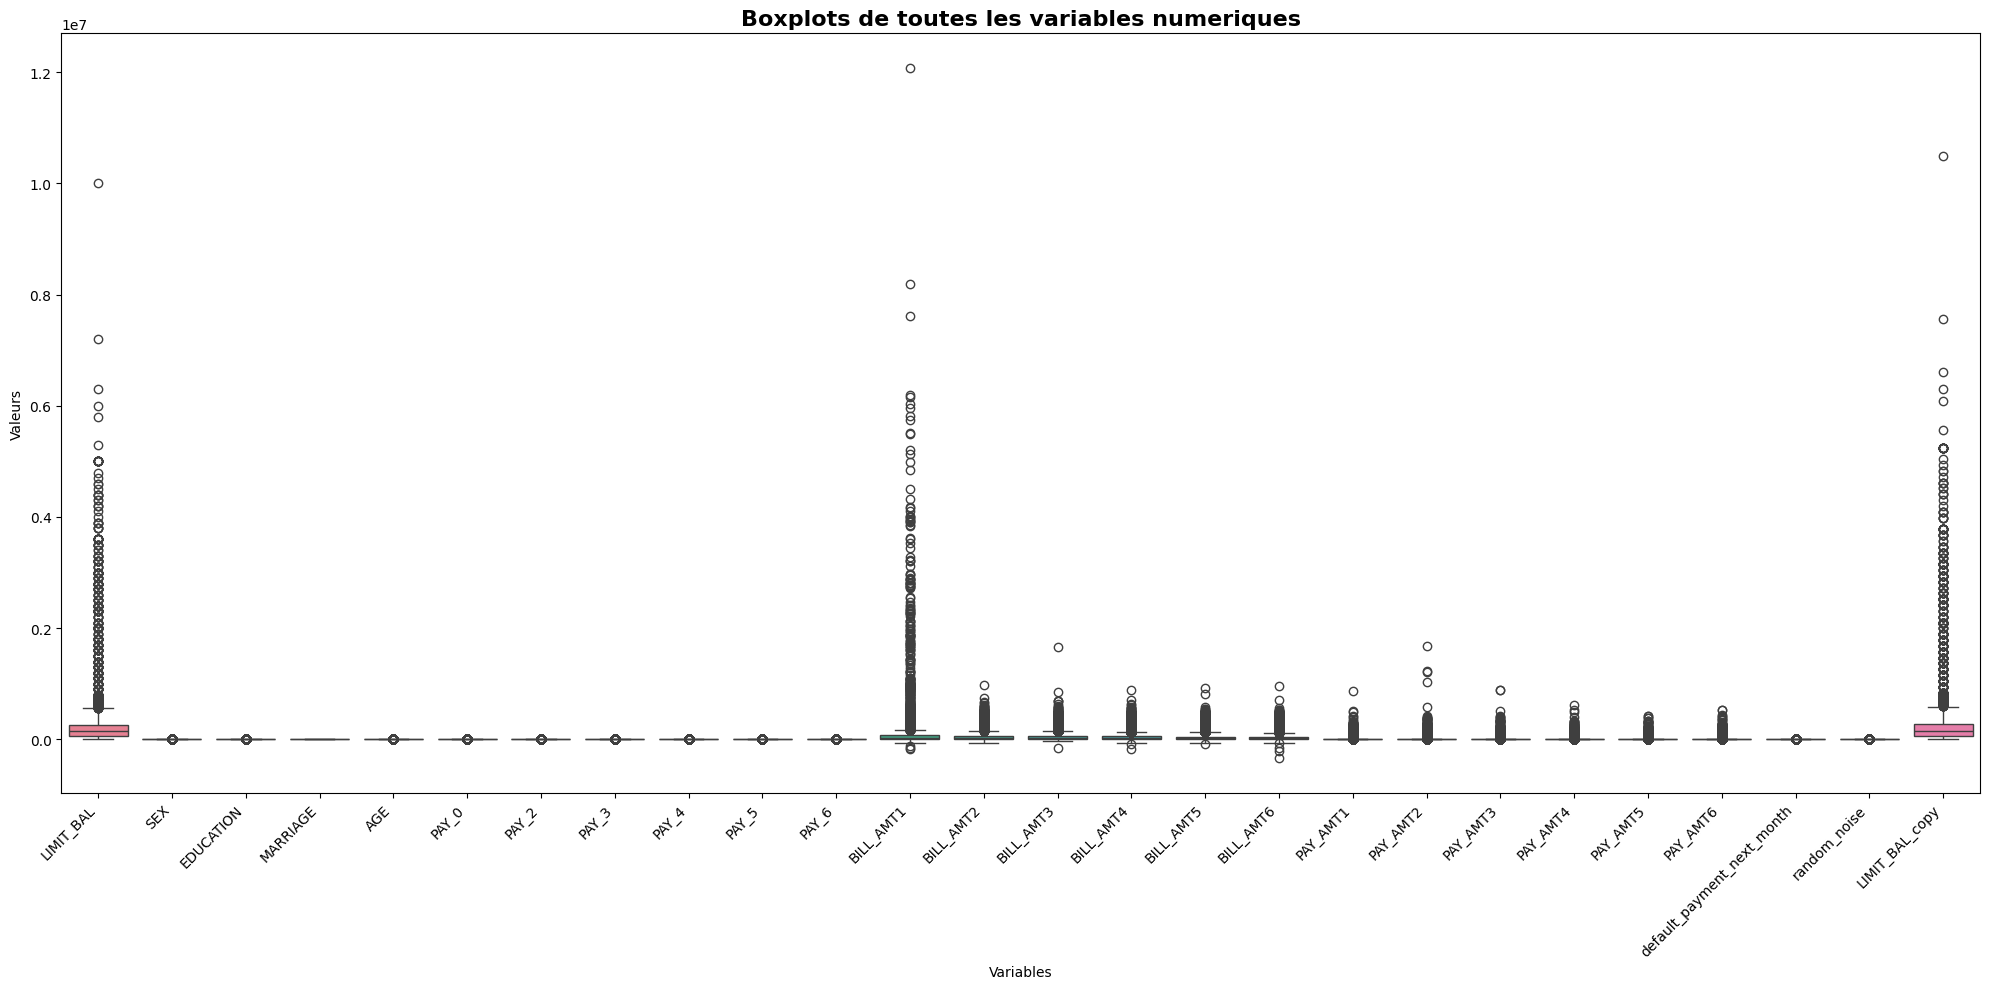

In [58]:
# Boxplot de toutes les variables numeriques
plt.figure(figsize=(20, 10))
sns.boxplot(data=df[num_cols])
plt.title("Boxplots de toutes les variables numeriques", fontsize=16, fontweight='bold')
plt.xlabel("Variables")
plt.ylabel("Valeurs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Detection Statistique des Outliers par la Methode IQR

In [59]:
# Calcul des outliers avec la methode IQR
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary[col] = {
        'Nombre_Outliers': len(outliers),
        'Pourcentage': (len(outliers) / len(df)) * 100,
        'Borne_Inferieure': lower_bound,
        'Borne_Superieure': upper_bound
    }

outlier_df = pd.DataFrame(outlier_summary).T.sort_values('Pourcentage', ascending=False)
print("Resume des outliers par colonne:")
print(outlier_df)

Resume des outliers par colonne:
                            Nombre_Outliers  Pourcentage  Borne_Inferieure  \
PAY_3                                2688.0    10.532503         -2.500000   
PAY_2                                2678.0    10.493319         -2.500000   
PAY_AMT2                             2540.0     9.952588      -5097.500000   
BILL_AMT5                            2319.0     9.086635     -71744.500000   
BILL_AMT6                            2294.0     8.988676     -71369.000000   
PAY_AMT1                             2227.0     8.726147      -5355.500000   
BILL_AMT4                            2205.0     8.639944     -77587.000000   
PAY_4                                2200.0     8.620352         -2.500000   
PAY_AMT3                             2196.0     8.604679      -6245.000000   
PAY_AMT6                             2184.0     8.557658      -5955.000000   
PAY_AMT5                             2153.0     8.436190      -5890.000000   
PAY_AMT4                       

### 3.4 Visualisation des Outliers

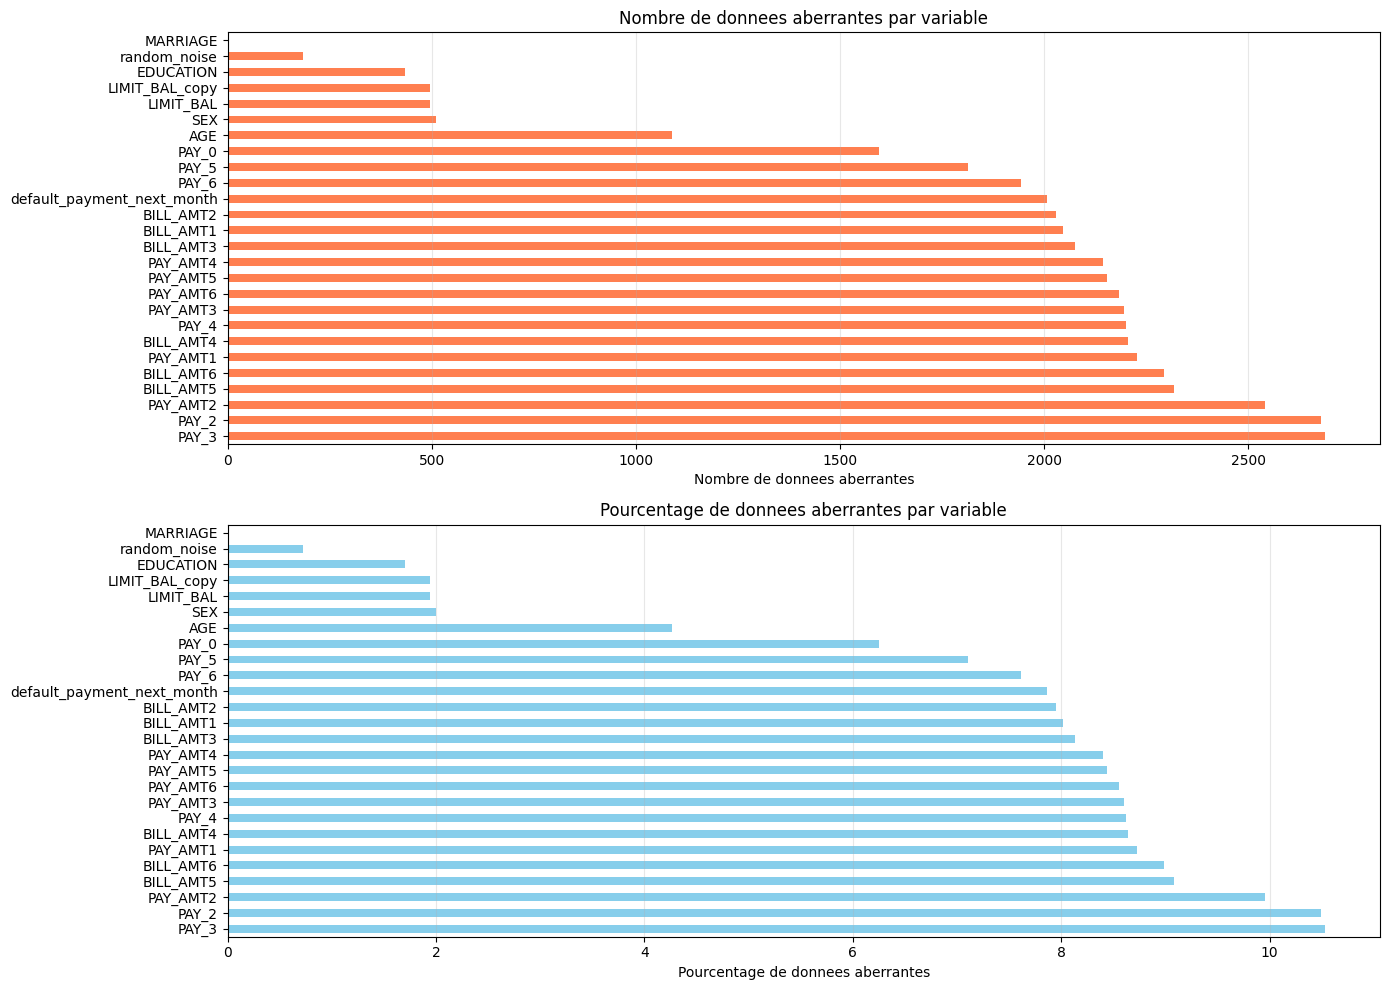

In [60]:
# Graphique des pourcentages d'outliers
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique en barres du nombre d'outliers
outlier_counts = pd.Series({col: outlier_summary[col]['Nombre_Outliers'] for col in num_cols})
outlier_counts.sort_values(ascending=False).plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_xlabel('Nombre de donnees aberrantes')
axes[0].set_title('Nombre de donnees aberrantes par variable')
axes[0].grid(axis='x', alpha=0.3)

# Graphique en barres du pourcentage d'outliers
outlier_pcts = pd.Series({col: outlier_summary[col]['Pourcentage'] for col in num_cols})
outlier_pcts.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='skyblue')
axes[1].set_xlabel('Pourcentage de donnees aberrantes')
axes[1].set_title('Pourcentage de donnees aberrantes par variable')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Analyse Statistique Descriptive

### 4.1 Statistiques Descriptives des Variables Numeriques

In [61]:
# Statistiques descriptives completes
stats_df = df[num_cols].describe().T
stats_df['Skewness'] = df[num_cols].skew()
stats_df['Kurtosis'] = df[num_cols].kurtosis()

print("Statistiques descriptives des variables numeriques:")
print(stats_df.round(3))

Statistiques descriptives des variables numeriques:
                              count        mean         std         min  \
LIMIT_BAL                   24261.0  207560.777  326640.411   10000.000   
SEX                         25521.0       3.556      13.638       1.000   
EDUCATION                   25521.0       1.845       0.801       0.000   
MARRIAGE                    25521.0       1.556       0.522       0.000   
AGE                         25521.0      34.852      11.608      -6.000   
PAY_0                       25521.0      -0.144       1.018      -2.000   
PAY_2                       25521.0      -0.242       1.097      -2.000   
PAY_3                       25521.0      -0.262       1.104      -2.000   
PAY_4                       25521.0      -0.307       1.071      -2.000   
PAY_5                       25521.0      -0.346       1.034      -2.000   
PAY_6                       25521.0      -0.366       1.058      -2.000   
BILL_AMT1                   24241.0   70728.419 

### 4.2 Histogrammes de Distribution

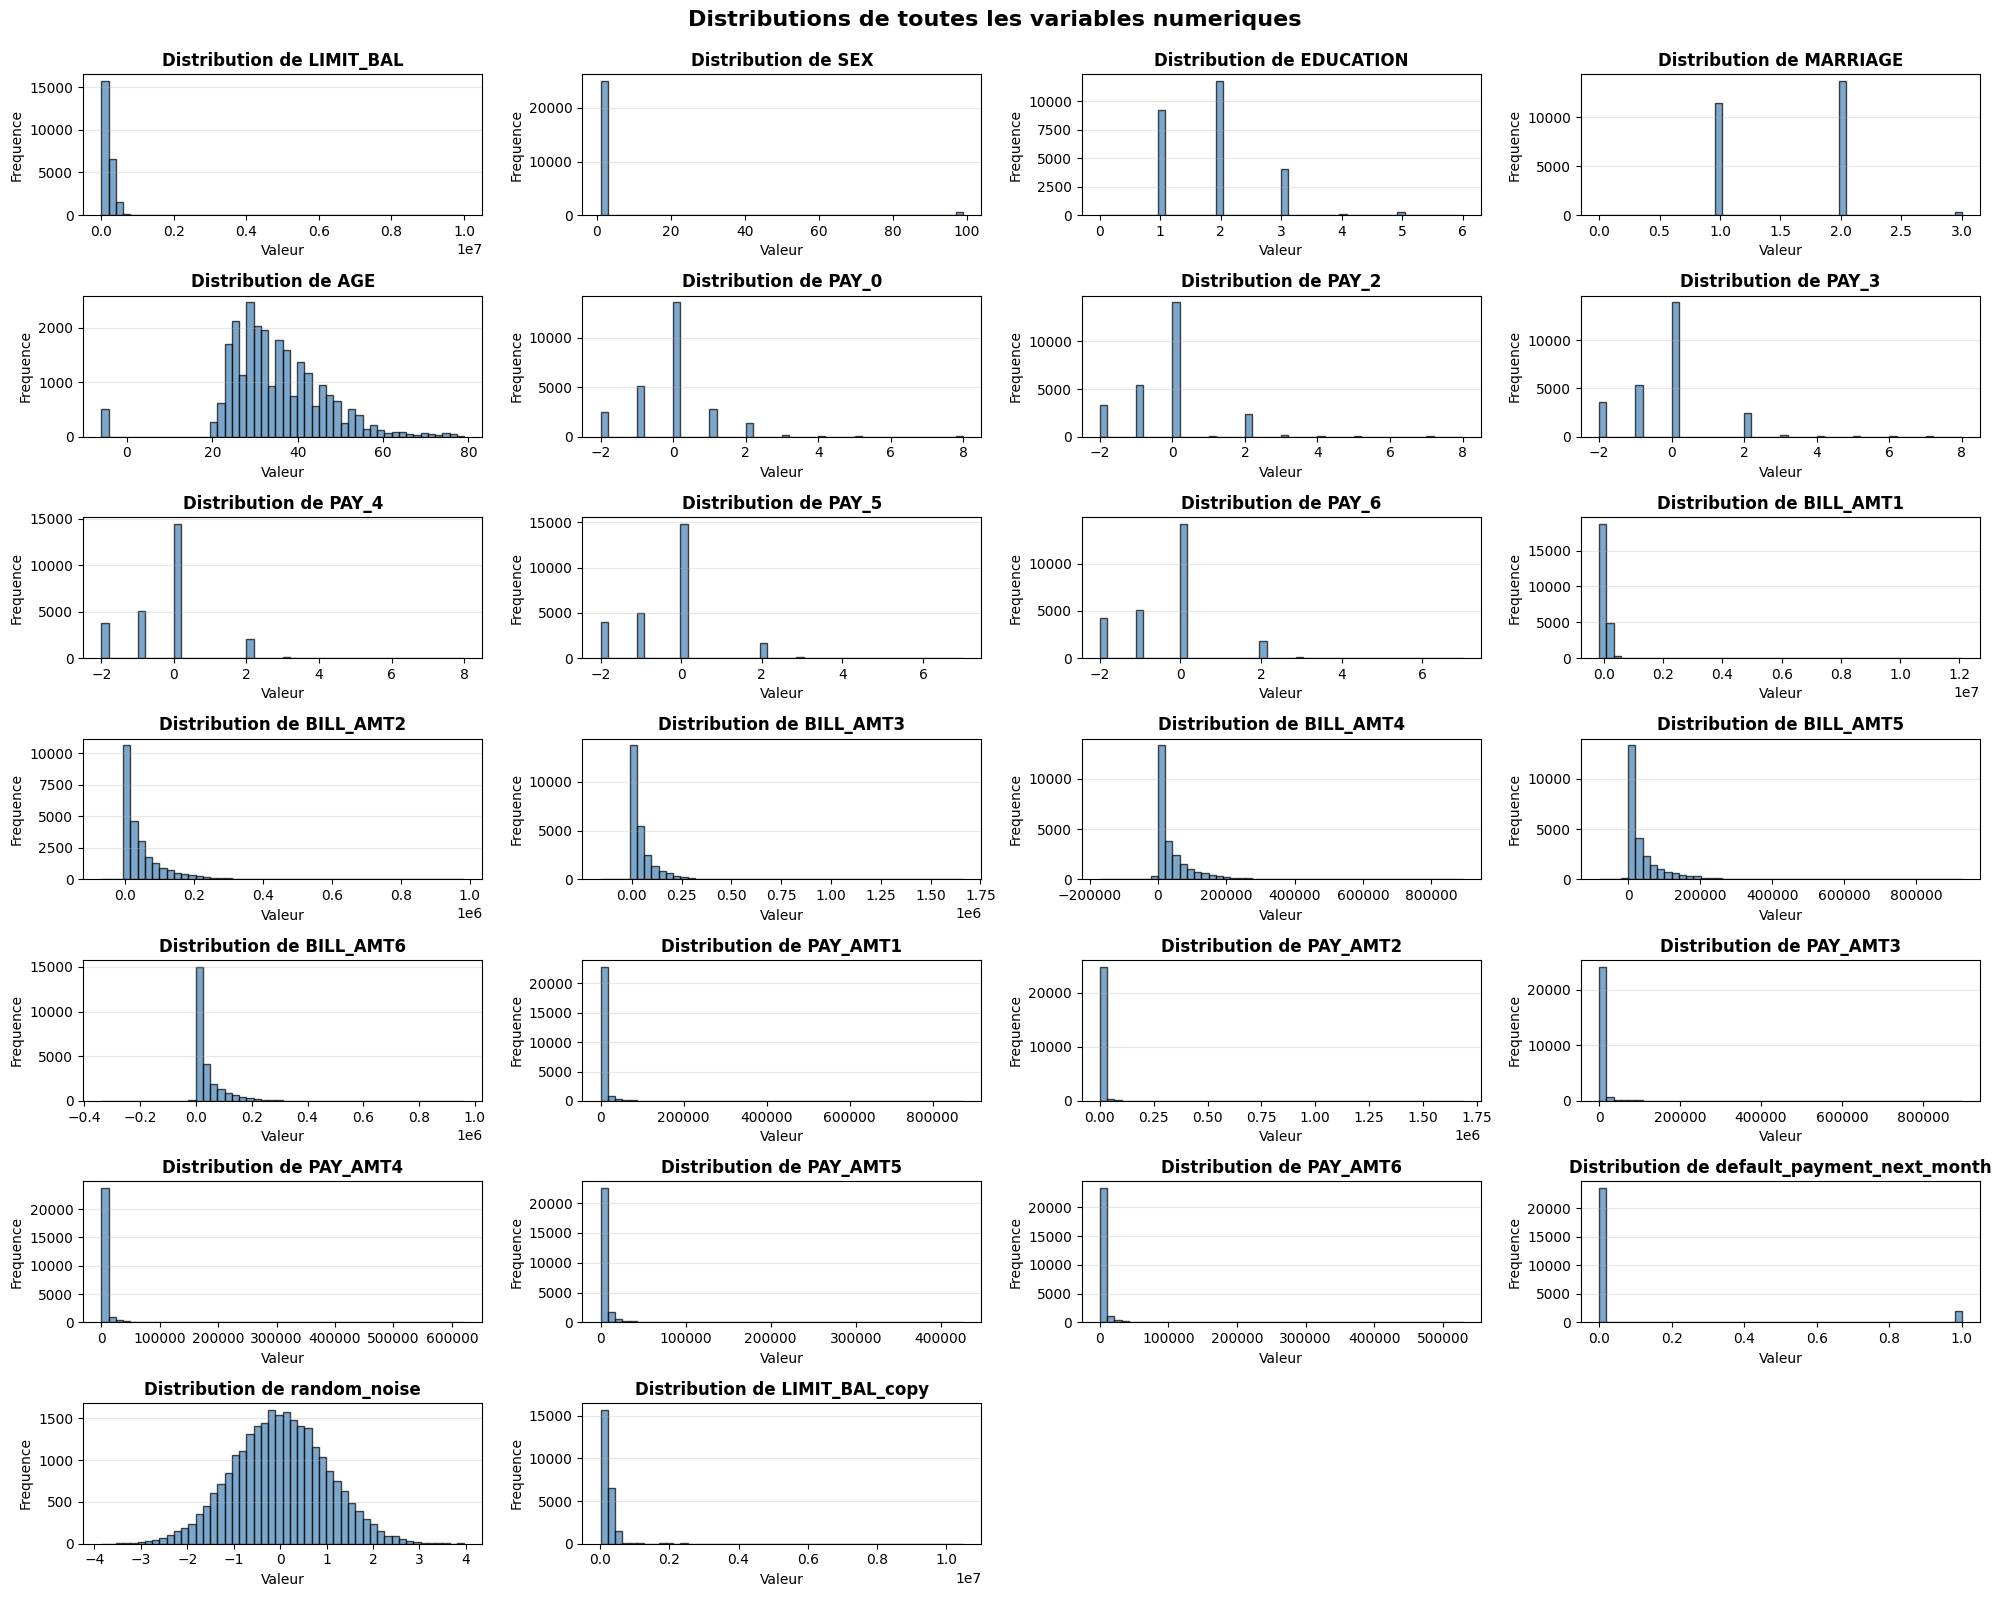

In [62]:
# Histogrammes des distributions
fig = plt.figure(figsize=(20, 16))

num_vars = len(num_cols)
cols_per_row = 4
rows = (num_vars + cols_per_row - 1) // cols_per_row

for idx, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, idx)
    plt.hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title(f'Distribution de {col}', fontweight='bold')
    plt.xlabel('Valeur')
    plt.ylabel('Frequence')
    plt.grid(axis='y', alpha=0.3)

plt.suptitle('Distributions de toutes les variables numeriques', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 4.3 Distributions avec Courbe de Densite

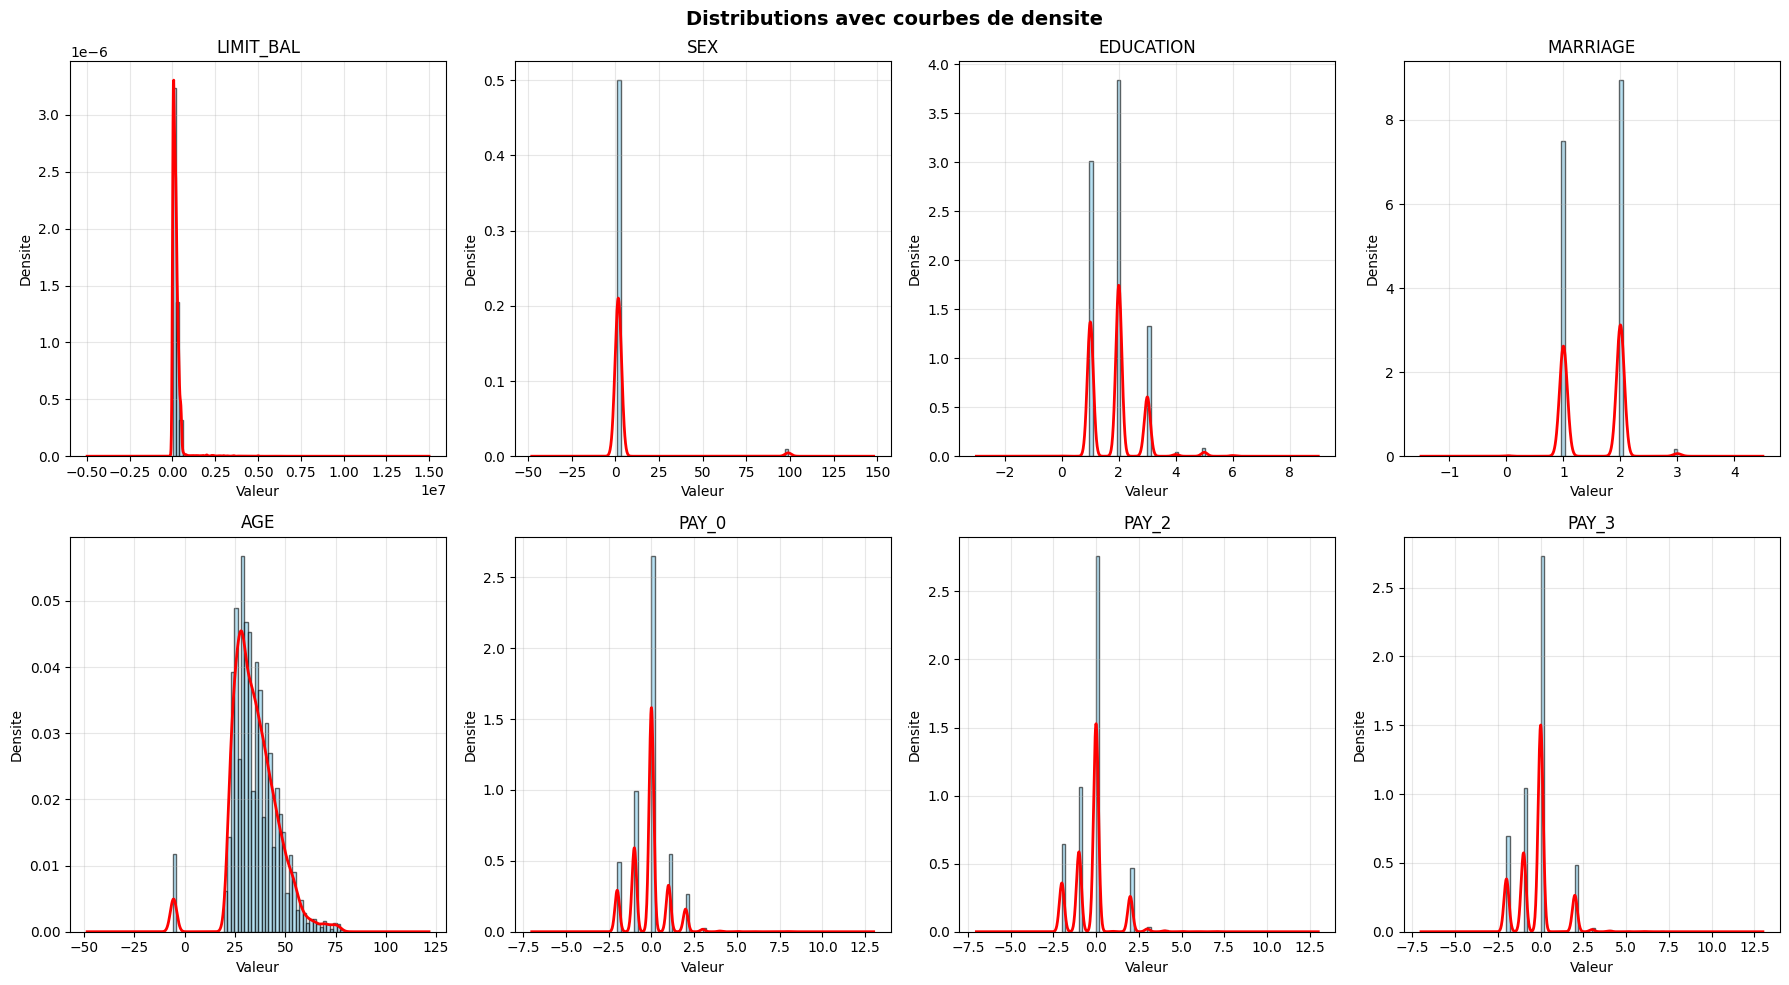

In [63]:
# Distributions avec courbes de densite pour les principales variables
main_vars = [col for col in num_cols if col != 'default_payment_next_month'][:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(main_vars):
    axes[idx].hist(df[col].dropna(), bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    df[col].dropna().plot(kind='kde', ax=axes[idx], color='red', linewidth=2)
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Valeur')
    axes[idx].set_ylabel('Densite')
    axes[idx].grid(alpha=0.3)

plt.suptitle('Distributions avec courbes de densite', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Analyse de la Variable Cible

### 5.1 Desequilibre de Classes

In [64]:
# Analyser la variable cible
target_col = 'default_payment_next_month'

print("Distribution brute de la classe cible:")
print(df[target_col].value_counts())
print("\nDistribution en pourcentage:")
print(df[target_col].value_counts(normalize=True) * 100)

Distribution brute de la classe cible:
default_payment_next_month
0    23515
1     2006
Name: count, dtype: int64

Distribution en pourcentage:
default_payment_next_month
0    92.139806
1     7.860194
Name: proportion, dtype: float64


### 5.2 Visualisation du Desequilibre

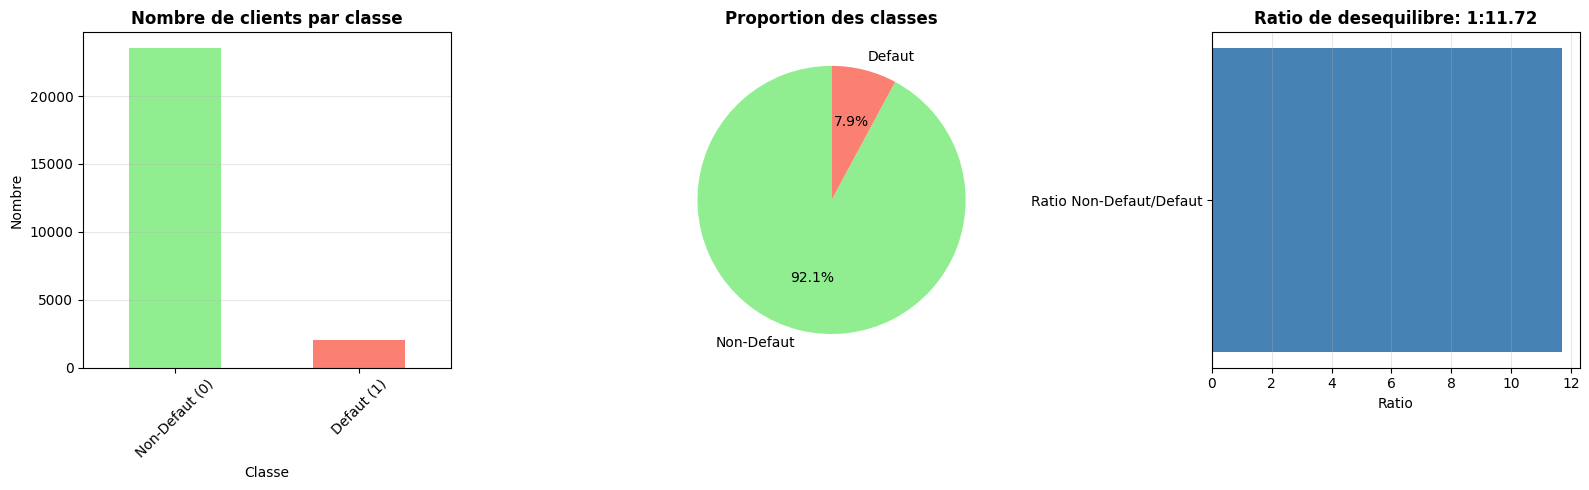


Information importante: Le dataset contient un desequilibre de classes.
Ratio: 11.72 clients non-defaut pour 1 client en defaut


In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Graphique en barres
target_counts = df[target_col].value_counts()
colors = ['lightgreen', 'salmon']
target_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Nombre de clients par classe', fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre')
axes[0].set_xticklabels(['Non-Defaut (0)', 'Defaut (1)'], rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Graphique circulaire
target_pct = df[target_col].value_counts(normalize=True) * 100
axes[1].pie(target_pct.values, 
            labels=['Non-Defaut', 'Defaut'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[1].set_title('Proportion des classes', fontweight='bold')

# Graphique de ratio
ratio = target_counts[0] / target_counts[1]
axes[2].barh(['Ratio Non-Defaut/Defaut'], [ratio], color='steelblue')
axes[2].set_xlabel('Ratio')
axes[2].set_title(f'Ratio de desequilibre: 1:{ratio:.2f}', fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInformation importante: Le dataset contient un desequilibre de classes.")
print(f"Ratio: {ratio:.2f} clients non-defaut pour 1 client en defaut")

## 6. Analyse des Variables Categoriques

### 6.1 Distribution des Variables Categoriques

In [66]:
# Variables categoriques communes
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

print("Distribution des variables categoriques:")
for col in categorical_features:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts().sort_index())
        print(f"Pourcentage:")
        print((df[col].value_counts(normalize=True).sort_index() * 100).round(2))

Distribution des variables categoriques:

SEX:
SEX
1      9762
2     15249
99      510
Name: count, dtype: int64
Pourcentage:
SEX
1     38.25
2     59.75
99     2.00
Name: proportion, dtype: float64

EDUCATION:
EDUCATION
0       14
1     9237
2    11758
3     4078
4      119
5      270
6       45
Name: count, dtype: int64
Pourcentage:
EDUCATION
0     0.05
1    36.19
2    46.07
3    15.98
4     0.47
5     1.06
6     0.18
Name: proportion, dtype: float64

MARRIAGE:
MARRIAGE
0       52
1    11496
2    13702
3      271
Name: count, dtype: int64
Pourcentage:
MARRIAGE
0     0.20
1    45.05
2    53.69
3     1.06
Name: proportion, dtype: float64


### 6.2 Visualisation des Variables Categoriques

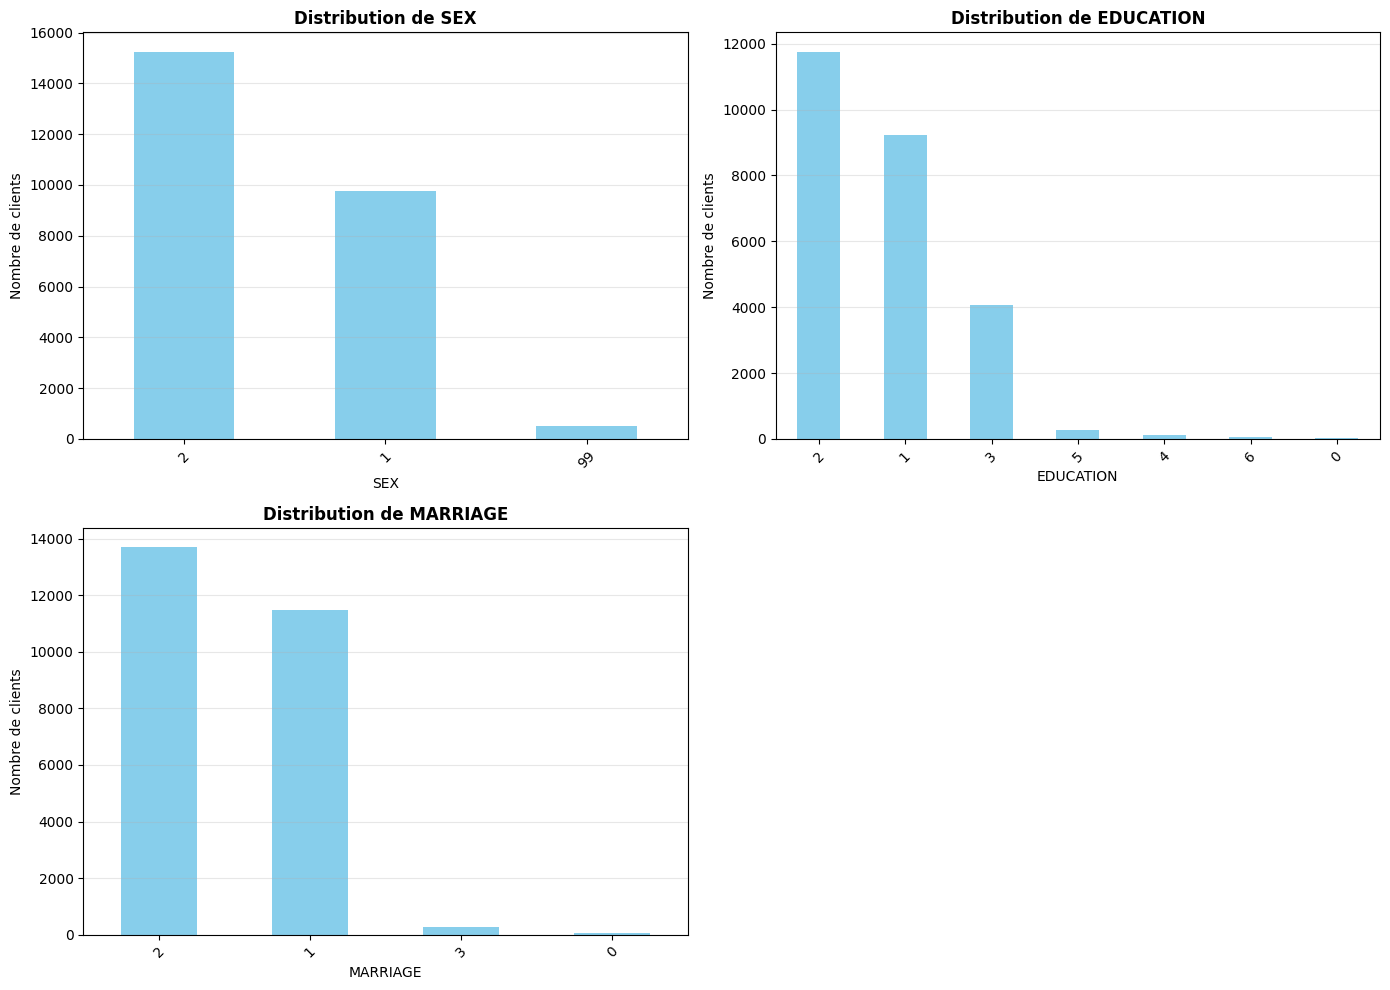

In [67]:
# Visualiser les distributions des variables categoriques
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cat_to_plot = [col for col in categorical_features if col in df.columns]

for idx, col in enumerate(cat_to_plot):
    ax = axes[idx]
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f'Distribution de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Nombre de clients')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Masquer les axes inutiles
for idx in range(len(cat_to_plot), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 7. Correlations et Multicollinearite

### 7.1 Matrice de Correlation Complete

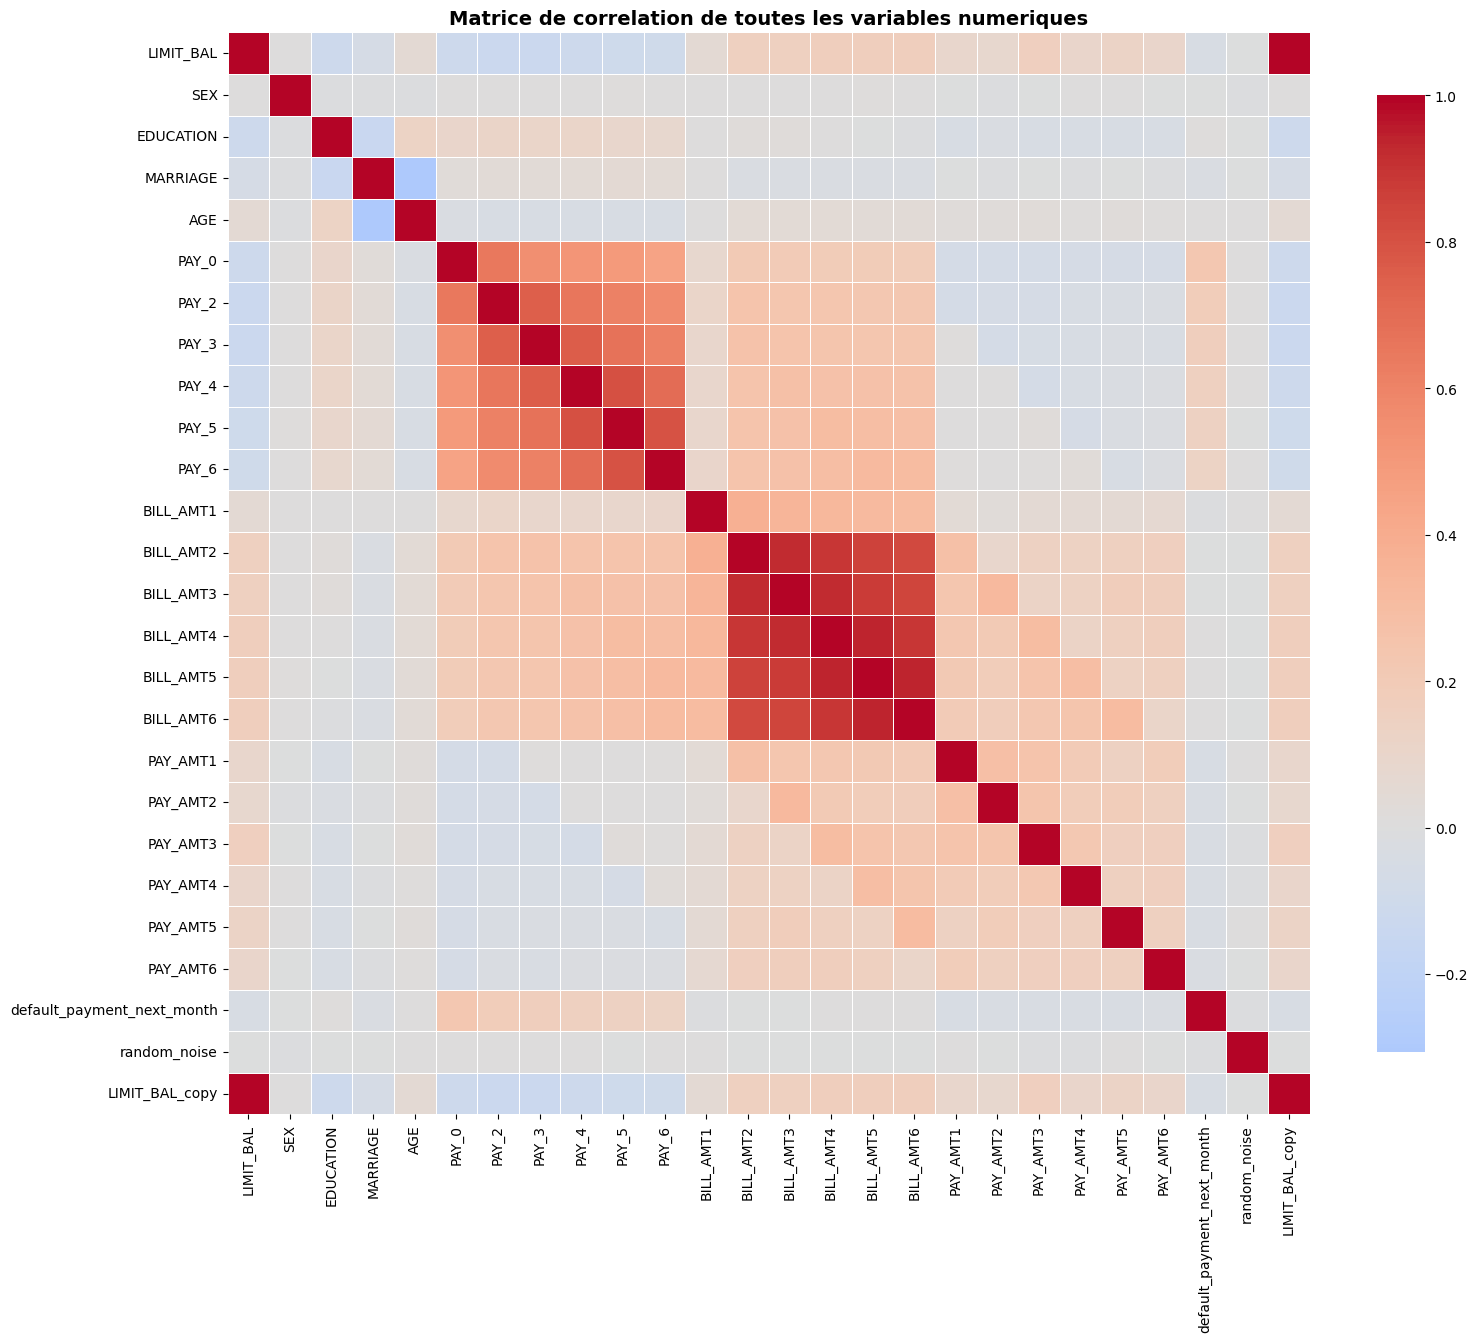

In [68]:
# Calculer la matrice de correlation
corr_matrix = df[num_cols].corr()

# Afficher la matrice
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, 
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Matrice de correlation de toutes les variables numeriques", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 7.2 Identification des Correlations Fortes

In [69]:
# Trouver les paires de variables fortement correlees
print("Paires de variables avec une correlation absolue > 0.8:")
print("="*60)

strong_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            strong_corr_pairs.append((col1, col2, corr_value))
            print(f"{col1} <-> {col2}: {corr_value:.4f}")

if len(strong_corr_pairs) == 0:
    print("Aucune paire avec correlation absolue > 0.8 trouvee")

print(f"\nTotal de paires fortement correlees: {len(strong_corr_pairs)}")

Paires de variables avec une correlation absolue > 0.8:
LIMIT_BAL <-> LIMIT_BAL_copy: 1.0000
PAY_4 <-> PAY_5: 0.8042
BILL_AMT2 <-> BILL_AMT3: 0.9246
BILL_AMT2 <-> BILL_AMT4: 0.8887
BILL_AMT2 <-> BILL_AMT5: 0.8557
BILL_AMT2 <-> BILL_AMT6: 0.8280
BILL_AMT3 <-> BILL_AMT4: 0.9197
BILL_AMT3 <-> BILL_AMT5: 0.8779
BILL_AMT3 <-> BILL_AMT6: 0.8480
BILL_AMT4 <-> BILL_AMT5: 0.9361
BILL_AMT4 <-> BILL_AMT6: 0.8963
BILL_AMT5 <-> BILL_AMT6: 0.9435

Total de paires fortement correlees: 12


### 7.3 Correlation avec la Variable Cible

Correlation des variables avec la cible:
PAY_0             0.225592
PAY_2             0.185007
PAY_3             0.168971
PAY_4             0.153895
PAY_5             0.143754
PAY_6             0.127802
EDUCATION         0.012754
AGE               0.009459
BILL_AMT5         0.003814
BILL_AMT6         0.002954
BILL_AMT4         0.002419
BILL_AMT2        -0.002730
BILL_AMT3        -0.003215
SEX              -0.004368
random_noise     -0.005950
BILL_AMT1        -0.011842
MARRIAGE         -0.020518
PAY_AMT6         -0.027707
PAY_AMT3         -0.030721
PAY_AMT5         -0.031914
PAY_AMT2         -0.034544
PAY_AMT4         -0.035388
LIMIT_BAL_copy   -0.038629
LIMIT_BAL        -0.038629
PAY_AMT1         -0.042703
Name: default_payment_next_month, dtype: float64


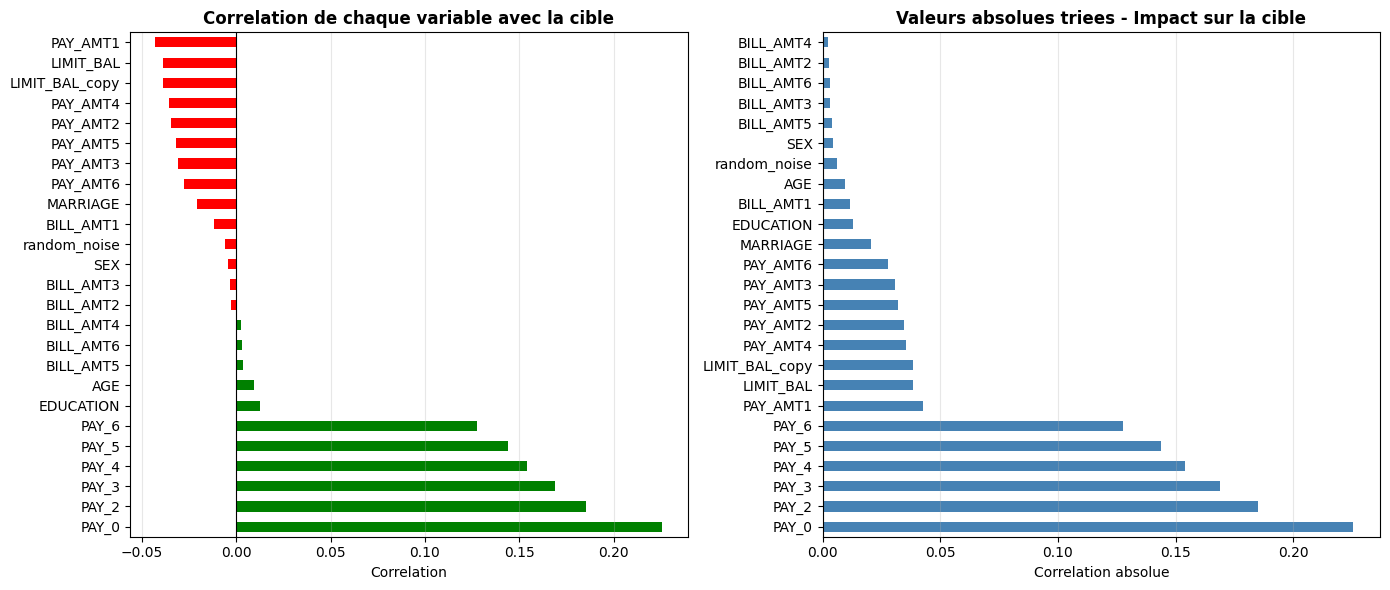

In [70]:
if target_col in df.columns:
    # Correlations avec la variable cible
    target_corr = df[num_cols].corr()[target_col].drop(target_col).sort_values(ascending=False)
    
    print("Correlation des variables avec la cible:")
    print(target_corr)
    
    # Visualiser les correlations avec la cible
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Graphique 1: Barres positives et negatives
    colors = ['green' if x > 0 else 'red' for x in target_corr.values]
    target_corr.plot(kind='barh', ax=axes[0], color=colors)
    axes[0].set_xlabel('Correlation')
    axes[0].set_title('Correlation de chaque variable avec la cible', fontweight='bold')
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[0].grid(axis='x', alpha=0.3)
    
    # Graphique 2: Valeurs absolues triees
    abs_corr = target_corr.abs().sort_values(ascending=False)
    abs_corr.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_xlabel('Correlation absolue')
    axes[1].set_title('Valeurs absolues triees - Impact sur la cible', fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Analyse de Covariance et Relations Bivariees

### 8.1 Scatterplots des Variables Principales

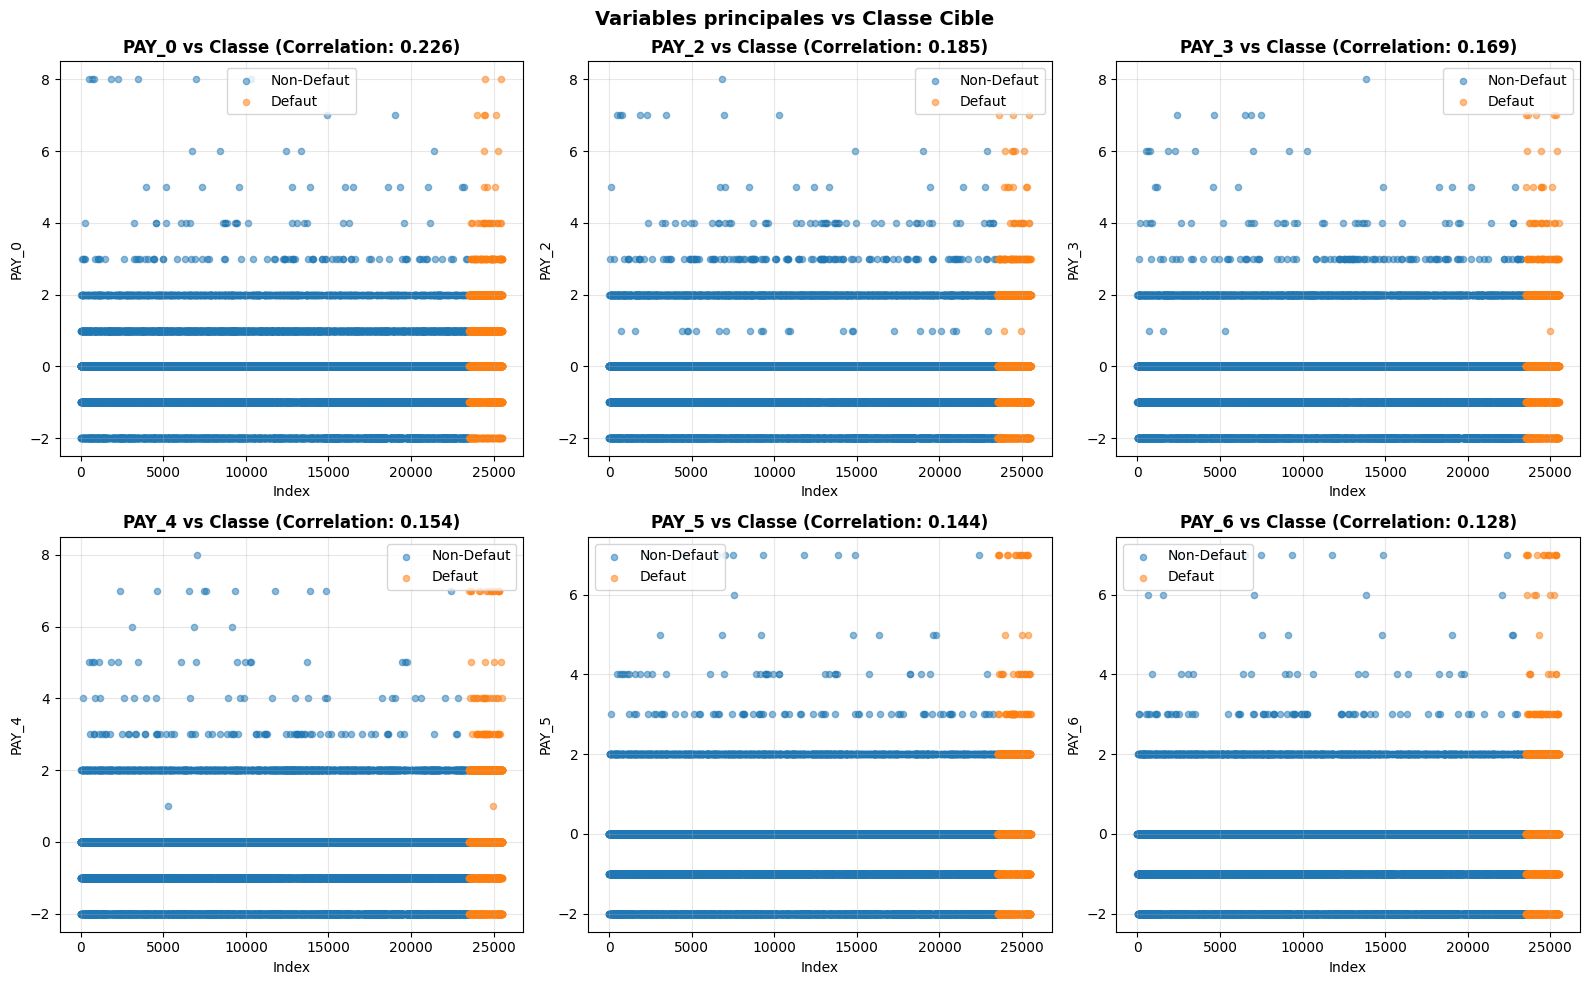

In [71]:
# Selectionner les variables les plus importantes
important_vars = target_corr.abs().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(important_vars):
    ax = axes[idx]
    
    # Scatterplot avec couleurs par classe
    for class_label in df[target_col].unique():
        mask = df[target_col] == class_label
        label = f"Defaut" if class_label == 1 else "Non-Defaut"
        ax.scatter(df[mask].index, df[mask][col], 
                  alpha=0.5, label=label, s=20)
    
    ax.set_title(f'{col} vs Classe (Correlation: {target_corr[col]:.3f})', fontweight='bold')
    ax.set_xlabel('Index')
    ax.set_ylabel(col)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Variables principales vs Classe Cible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Analyse des Tendances Temporelles et Patterns

### 9.1 Distribution par Classe pour Variables Continues

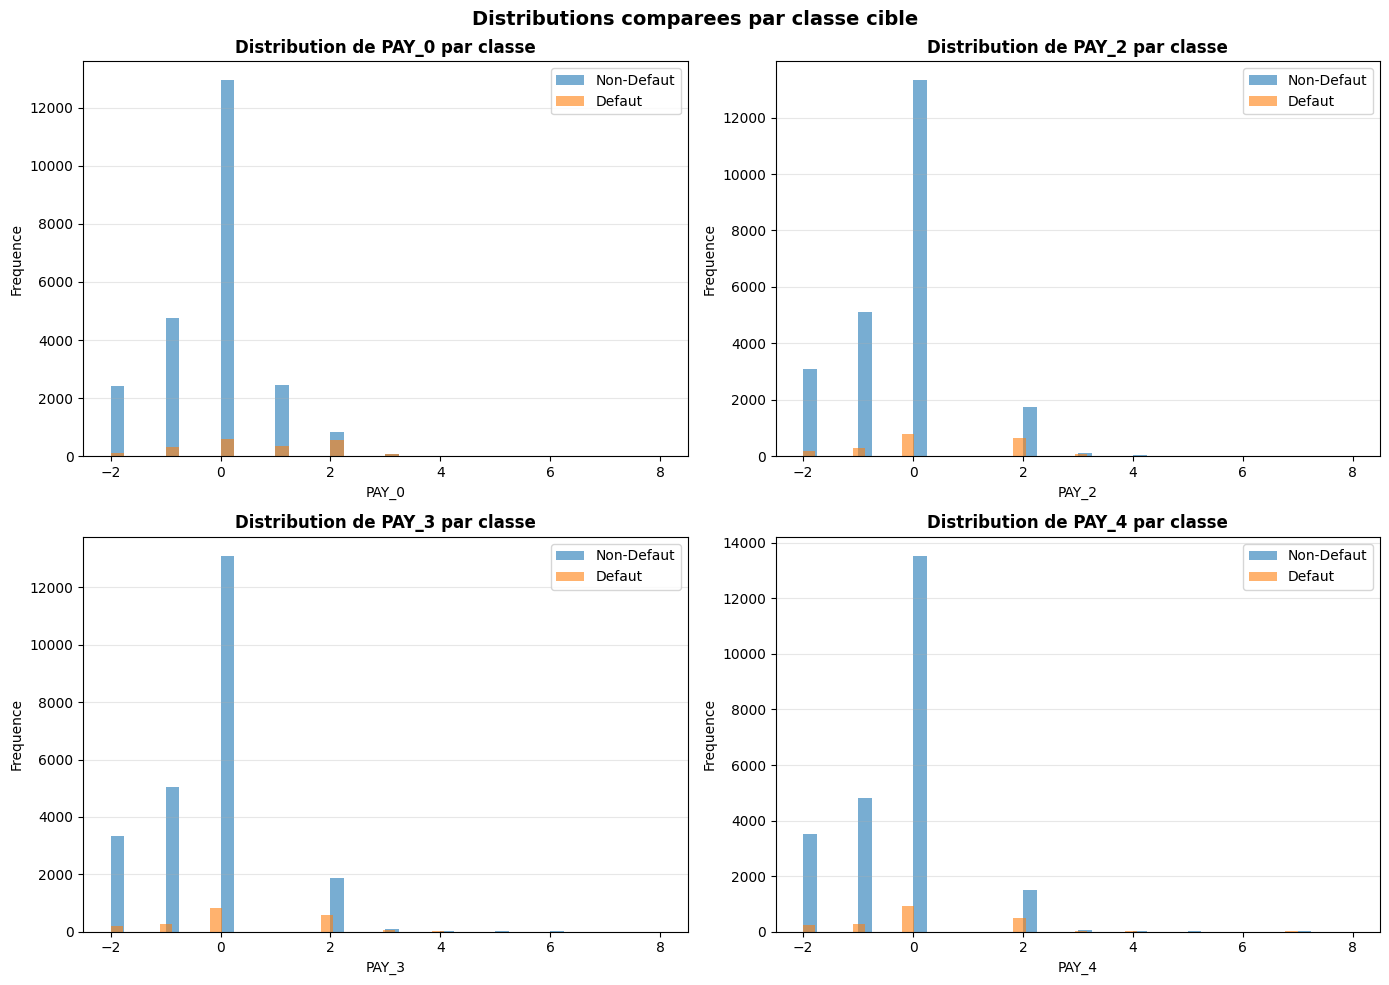

In [72]:
# Comparer les distributions par classe
top_vars = target_corr.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(top_vars):
    ax = axes[idx]
    
    for class_label in sorted(df[target_col].unique()):
        data = df[df[target_col] == class_label][col].dropna()
        label = f"Defaut" if class_label == 1 else "Non-Defaut"
        ax.hist(data, bins=40, alpha=0.6, label=label)
    
    ax.set_title(f'Distribution de {col} par classe', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequence')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distributions comparees par classe cible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 Boxplots Compares par Classe

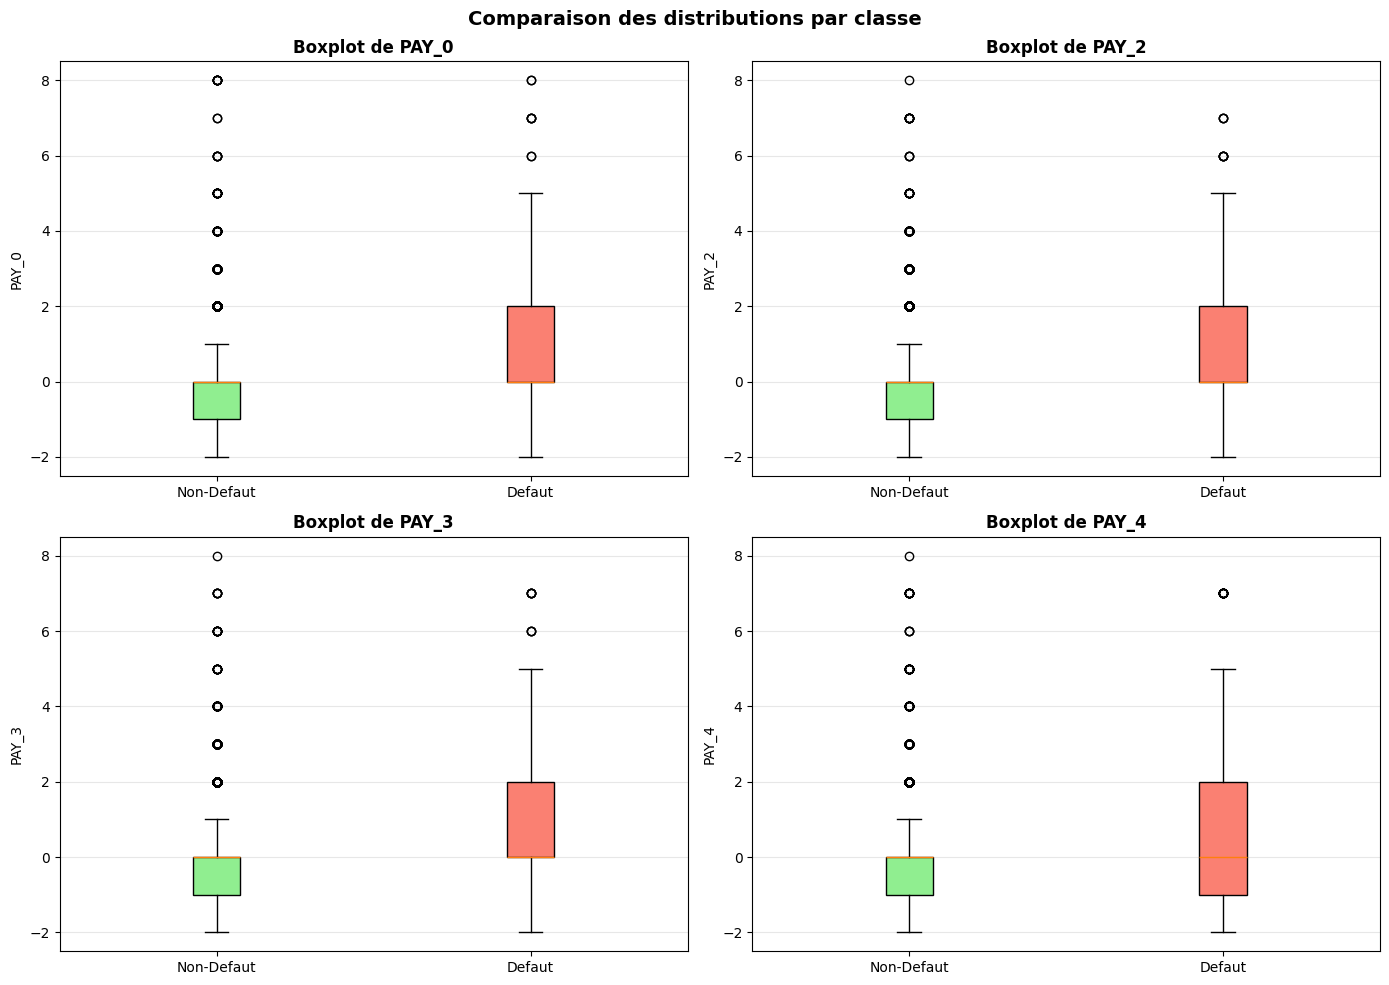

In [73]:
# Boxplots compares
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(top_vars):
    ax = axes[idx]
    
    # Preparer les donnees pour le boxplot
    data_to_plot = [df[df[target_col] == 0][col].dropna(),
                    df[df[target_col] == 1][col].dropna()]
    
    bp = ax.boxplot(data_to_plot, labels=['Non-Defaut', 'Defaut'],
                     patch_artist=True)
    
    # Colorer les boites
    colors = ['lightgreen', 'salmon']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'Boxplot de {col}', fontweight='bold')
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparaison des distributions par classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Analyse Resumee et Conclusions

### 10.1 Resume des Trouvailles Principales

In [74]:
print("="*70)
print("RESUME DE L'ANALYSE EXPLORATOIRE")
print("="*70)

print(f"\n1. STRUCTURE DU DATASET:")
print(f"   Nombre total d'observations: {df.shape[0]:,}")
print(f"   Nombre de variables: {df.shape[1]}")
print(f"   Variables numeriques: {len(num_cols)}")
print(f"   Variables categoriques: {len(cat_cols)}")

print(f"\n2. VALEURS MANQUANTES:")
missing_total = df.isnull().sum().sum()
print(f"   Total de valeurs manquantes: {missing_total}")
if missing_total == 0:
    print("   Conclusion: Aucune valeur manquante detectée")
else:
    print(f"   Pourcentage de donnees manquantes: {(missing_total / (df.shape[0] * df.shape[1]) * 100):.2f}%")

print(f"\n3. VALEURS ABERRANTES:")
total_outliers = sum(outlier_summary[col]['Nombre_Outliers'] for col in num_cols)
print(f"   Total de donnees aberrantes detectees: {total_outliers:,}")
print(f"   Variables les plus affectees: {outlier_df.head(3).index.tolist()}")

print(f"\n4. CLASSE CIBLE:")
print(f"   Classe 0 (Non-Defaut): {(df[target_col] == 0).sum():,} clients ({(df[target_col] == 0).sum()/len(df)*100:.1f}%)")
print(f"   Classe 1 (Defaut): {(df[target_col] == 1).sum():,} clients ({(df[target_col] == 1).sum()/len(df)*100:.1f}%)")
print(f"   Desequilibre: Ratio de {ratio:.1f}:1")

print(f"\n5. VARIABLES LES PLUS CORRELEES AVEC LA CIBLE:")
for i, (var, corr_val) in enumerate(target_corr.abs().nlargest(5).items(), 1):
    actual_corr = target_corr[var]
    print(f"   {i}. {var}: {actual_corr:.4f}")

print(f"\n6. MULTICOLLINEARITE:")
print(f"   Nombre de paires avec correlation > 0.8: {len(strong_corr_pairs)}")
if len(strong_corr_pairs) > 0:
    print("   Paires principales:")
    for col1, col2, corr in strong_corr_pairs[:3]:
        print(f"      - {col1} <-> {col2}: {corr:.4f}")
else:
    print("   Pas de probleme majeur de multicollinearite")

print("\n" + "="*70)

RESUME DE L'ANALYSE EXPLORATOIRE

1. STRUCTURE DU DATASET:
   Nombre total d'observations: 25,521
   Nombre de variables: 27
   Variables numeriques: 26
   Variables categoriques: 1

2. VALEURS MANQUANTES:
   Total de valeurs manquantes: 5076
   Pourcentage de donnees manquantes: 0.74%

3. VALEURS ABERRANTES:
   Total de donnees aberrantes detectees: 44,548
   Variables les plus affectees: ['PAY_3', 'PAY_2', 'PAY_AMT2']

4. CLASSE CIBLE:
   Classe 0 (Non-Defaut): 23,515 clients (92.1%)
   Classe 1 (Defaut): 2,006 clients (7.9%)
   Desequilibre: Ratio de 11.7:1

5. VARIABLES LES PLUS CORRELEES AVEC LA CIBLE:
   1. PAY_0: 0.2256
   2. PAY_2: 0.1850
   3. PAY_3: 0.1690
   4. PAY_4: 0.1539
   5. PAY_5: 0.1438

6. MULTICOLLINEARITE:
   Nombre de paires avec correlation > 0.8: 12
   Paires principales:
      - LIMIT_BAL <-> LIMIT_BAL_copy: 1.0000
      - PAY_4 <-> PAY_5: 0.8042
      - BILL_AMT2 <-> BILL_AMT3: 0.9246



### 10.2 Recommendations pour le Nettoyage des Donnees

In [75]:
recommendations = f"""
RECOMMANDATIONS POUR LE NETTOYAGE ET LA PREPARATION:

1. TRAITEMENT DES DONNEES MANQUANTES:
   - Aucune action requise si aucune donnee manquante
   - Sinon, utiliser l'imputation par la mediane pour les variables numeriques
   
2. TRAITEMENT DES VALEURS ABERRANTES:
   - Conserver les outliers (donnees financieres legitimes)
   - Appliquer une standardisation robuste (RobustScaler) qui est resistante aux valeurs extremes
   - Envisager une transformation logarithmique pour les variables tres asymetriques
   
3. GESTION DU DESEQUILIBRE DE CLASSES:
   - Appliquer SMOTE sur l'ensemble d'entraînement uniquement
   - Utiliser class_weight='balanced' dans les modeles de classification
   - Utiliser des metriques appropriees: ROC-AUC et Recall, pas seulement Accuracy
   
4. ENCODAGE DES VARIABLES CATEGORIQUES:
   - Appliquer OneHotEncoder avec drop='first' pour eviter la multicollinearite
   
5. SELECTION DE VARIABLES:
   - Utiliser SelectKBest ou mutual_info_classif pour reduire la dimensionalite
   - Tenir compte des correlations fortes identifiees
   
6. NORMALISATION:
   - Appliquer RobustScaler pour les variables numeriques
   - Eviter StandardScaler qui est sensible aux outliers
"""

print(recommendations)


RECOMMANDATIONS POUR LE NETTOYAGE ET LA PREPARATION:

1. TRAITEMENT DES DONNEES MANQUANTES:
   - Aucune action requise si aucune donnee manquante
   - Sinon, utiliser l'imputation par la mediane pour les variables numeriques

2. TRAITEMENT DES VALEURS ABERRANTES:
   - Conserver les outliers (donnees financieres legitimes)
   - Appliquer une standardisation robuste (RobustScaler) qui est resistante aux valeurs extremes
   - Envisager une transformation logarithmique pour les variables tres asymetriques

3. GESTION DU DESEQUILIBRE DE CLASSES:
   - Appliquer SMOTE sur l'ensemble d'entraînement uniquement
   - Utiliser class_weight='balanced' dans les modeles de classification
   - Utiliser des metriques appropriees: ROC-AUC et Recall, pas seulement Accuracy

4. ENCODAGE DES VARIABLES CATEGORIQUES:
   - Appliquer OneHotEncoder avec drop='first' pour eviter la multicollinearite

5. SELECTION DE VARIABLES:
   - Utiliser SelectKBest ou mutual_info_classif pour reduire la dimensionalite
   - 

## 11. Pret pour les Etapes Suivantes

In [76]:
print("Etapes suivantes:")
print("")
print("1. Nettoyage et transformation des donnees")
print("2. Selection et ingenierie des caracteristiques")
print("3. Division des donnees train/test")
print("4. Equilibrage des classes (SMOTE)")
print("5. Normalisation/standardisation")
print("6. Entrainement de modeles de classification")
print("7. Evaluation et comparaison des modeles")
print("8. Optimisation des hyperparametres")
print("9. Validation finale et interpretabilite")

Etapes suivantes:

1. Nettoyage et transformation des donnees
2. Selection et ingenierie des caracteristiques
3. Division des donnees train/test
4. Equilibrage des classes (SMOTE)
5. Normalisation/standardisation
6. Entrainement de modeles de classification
7. Evaluation et comparaison des modeles
8. Optimisation des hyperparametres
9. Validation finale et interpretabilite
